# Stage 1: GTEx Transcript Expression

This notebook compares twelve frozen encoders on transcript expression across 30 human tissues, using genomic DNA, transcripts, and proteins as inputs. The [shared overview](../docs/stage1-overview.md) describes the models and research questions; the [stability notebook](Stage1_stability.ipynb) provides the companion coding-sequence experiment.

Follow the [data and expression labels](#GTEx-data), [encoder inputs and embeddings](#GTEx-encoder-inputs-and-embeddings), and [Track A predictions](#GTEx-Track-A:-Expression-decodability), including the [published-split comparison](#GTEx-published-split-comparison), before [Track B geometry](#GTEx-Track-B:-Cross-modal-geometry) and [Track C attention and diagnostics](#GTEx-Track-C:-Attention-and-diagnostics).

**Saved results.** Outputs and execution counts come from a top-to-bottom run of this notebook; [run records](../docs/run-records.md#recorded-runs) identify it. For a new run, start a fresh kernel and run this notebook from its own setup, using `Code/` as the working directory. See [environment setup](../README.md#setup).


## Distinct inputs: GTEx transcript expression

In the [stability experiment](Stage1_stability.ipynb), the inputs share one coding-sequence origin; translation loses synonymous codon distinctions. This notebook repeats the main analyses on a dataset in which each modality is the sequence of a different molecule: DNA encoders read genomic DNA around the transcription start site, RNA encoders read the transcript, and protein encoders read the protein. The question is whether the stability findings change when the DNA input holds sequence the protein lacks, such as the promoter, and the transcript holds its untranslated regions.

The data come from IsoFormer's GTEx transcript-expression task ([IsoFormer](../Papers/core/Multi-Modal-Transfer-Learning.pdf), Section 4 and Appendix A; [dataset](https://huggingface.co/datasets/InstaDeepAI/multi_omics_transcript_expression)). Each row is one transcript, labeled with its expression in 30 human tissues: GTEx transcripts per million, averaged over individuals and log-transformed by the dataset's authors. The analyses use the same maintained `shared_code` methods as the stability experiment; the text below explains what differs and links to the shared method guides. Variables retain their `gtex_` or `GTEX_` names. This notebook initializes its own settings and data, without importing or executing the stability notebook.

| Encoders | GTEx input | Stability input |
|---|---|---|
| DNA: Nucleotide Transformer 500M human-ref, Nucleotide Transformer v2 100M multi-species, DNABERT-2, HyenaDNA large | 6,000 nucleotides of the GRCh38 reference genome centered on the transcription start site, read on the transcript's strand | The coding sequence in DNA letters |
| RNA, one token per nucleotide: RNA-FM, RiNALMo 150M | The full transcript, with both untranslated regions, in RNA letters | The coding sequence in RNA letters |
| RNA, one token per codon: mRNA-FM, CaLM | The coding sequence in RNA letters, because a codon tokenizer needs an in-frame sequence | The same |
| Protein: ESM-2 8M, 35M, and 150M, ProtBERT | The annotated protein | The translated coding sequence |

The experiment asks the three track questions again:

- **Track A.** How much of a transcript's expression across tissues can a linear probe recover from each frozen embedding, compared with sequence lengths and composition alone? Do concatenated embeddings help, as trained fusion does in IsoFormer?
- **Track B.** Do the agreement patterns found on the stability data hold when the DNA input is a different sequence from the transcript and the protein: agreement following tokenization more than modality, and agreement involving nucleotide encoders being mostly composition?
- **Track C.** With untranslated regions available, does RNA-encoder attention concentrate at candidate stability patterns in 3' untranslated regions beyond what position and local sequence explain? Do sample-level alignment and representational similarity relate to prediction?

---

## Setup

### Imports

Imports are grouped by purpose; the analysis functions come from the shared `shared_code` package. The next cell sets `PYTORCH_ENABLE_MPS_FALLBACK` with `setdefault` before importing PyTorch, preserving any existing value. This ordering matters when using the Apple GPU backend. See [Notebook dependencies](../README.md#notebook-dependencies) for environment preparation and MPS fallback details.


In [1]:
# Standard library
import itertools
import os

# Run any operation the Apple GPU backend lacks on the CPU; must precede importing torch
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

# Data handling and pretrained encoders
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

# Shared project code in Code/shared_code
from shared_code import analysis, datasets, embeddings, encoders, sequences, splits
from shared_code.notebook import show_source

### Figure export settings

The optional [figure exports](#Figure-exports-from-completed-results) use the captured result state in `docs/figures/gtex/results.json`. This setting loads that explicitly selected snapshot; `GTEX_FIGURE_SOURCE` can select another compatible result file. `GTEX_FIGURE_DIR` overrides the destination; the default is `docs/figures/gtex/` under this repository, independent of the notebook working directory. Running an export replaces files with the same names in that destination.

In [ ]:
from datetime import datetime, timezone
from pathlib import Path
import hashlib
import itertools
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

gtex_figure_repo_root = Path(__import__("shared_code").__file__).resolve().parents[2]
GTEX_FIGURE_DIR = Path(os.environ.get("GTEX_FIGURE_DIR") or (gtex_figure_repo_root / "docs" / "figures" / "gtex"))
GTEX_FIGURE_SOURCE = Path(os.environ.get("GTEX_FIGURE_SOURCE") or (gtex_figure_repo_root / "docs" / "figures" / "gtex" / "results.json"))
if not GTEX_FIGURE_SOURCE.is_file():
    raise RuntimeError(f"GTEx captured result snapshot is missing: {GTEX_FIGURE_SOURCE}. No research was rerun.")
GTEX_FIGURE_SNAPSHOT = json.loads(GTEX_FIGURE_SOURCE.read_text(encoding="utf-8"))
GTEX_FIGURE_COLORS = {"DNA": "#2879C2", "RNA": "#079B77", "protein": "#E06430"}
GTEX_FIGURE_STYLE = {
    "font.family": "DejaVu Sans", "font.size": 12, "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "svg.fonttype": "none", "pdf.fonttype": 42,
}

### Implementation displays

`SHOW_IMPLEMENTATION = False` gives compact links to the maintained functions beside each method. Set it to `True`, run the setting, and rerun a chosen `show_source` cell to see its full Python source. These display cells inspect code without executing the analysis functions. See [Reading implementation code](../README.md#reading-implementation-code) for usage and source-link behavior.


In [2]:
SHOW_IMPLEMENTATION = False

### Analysis settings

Run these settings groups in order before the GTEx analyses, using `Code/` as the working directory. They select the encoders, pilot dataset, comparison sets, attention limits, and embedding cache paths.

#### Seed

`SEED` initializes PyTorch and is passed to the analyses that use it. `PROBE_SEED` separately selects the pinned probe folds; see [Reproducibility](#Reproducibility) for the three seed roles.


In [3]:
SEED = 42  # Sampling, CCA/stochastic analyses, and PyTorch initialization
PROBE_SEED = 42  # Pinned grouped probe folds; further assignments use range(N_FOLD_ASSIGNMENTS)
torch.manual_seed(SEED);

#### Encoder selection and pairs

`ENCODER_KEYS` sets the encoder and table order; `REFERENCE_KEYS` selects the one-per-modality concatenation. `PAIRS` enumerates every unordered encoder pair in that order. The [shared model overview](../docs/stage1-overview.md#models-and-input-settings) describes pretraining and model selection; the registry table below records checkpoints, revisions, and token limits. See [tokens and input limits](../docs/methods/inputs-and-embeddings.md#tokens-and-input-limits) for the distinction between tokens and sequence characters.


In [4]:
# Encoders from the shared_code.encoders registry; this order sets the row and column order of every table
ENCODER_KEYS = [
    "nt500m", "ntv2_100m", "dnabert2", "hyenadna",   # DNA
    "rnafm", "rinalmo", "mrnafm", "calm",            # RNA: single-nucleotide, then codon tokens
    "esm2_8m", "esm2_35m", "esm2_150m", "protbert",  # protein
]
ENCODERS = [encoders.ENCODERS[key] for key in ENCODER_KEYS]
LABELS = {e.key: e.label for e in ENCODERS}
MODALITY = {e.key: e.modality for e in ENCODERS}

# One encoder per modality, in ENCODER_KEYS order
REFERENCE_KEYS = ["nt500m", "rnafm", "esm2_35m"]

PAIRS = list(itertools.combinations(ENCODER_KEYS, 2))

#### Probe and attention limits

`N_FOLD_ASSIGNMENTS` controls the additional partitions for [probe evaluation](../docs/methods/linear-probing.md#evaluation-and-interpretation). `ATTENTION_ENCODERS` identifies the registry entries that return attention weights; the next group selects those appropriate for untranslated regions. `ATTENTION_NULL_PERMUTATIONS` controls the number of [attention null shuffles](../docs/methods/attention-and-motifs.md#controlling-the-attention-test-for-position-and-codons).


In [5]:
# Probe evaluation and attention nulls use the same values as the saved run.
N_FOLD_ASSIGNMENTS = 10
ATTENTION_ENCODERS = [
    k for k in ENCODER_KEYS if MODALITY[k] in ("DNA", "RNA") and encoders.ENCODERS[k].attention
]
ATTENTION_NULL_PERMUTATIONS = 500

#### GTEx comparison and UTR attention

`GTEX_DATASET` selects the [distinct-input experiment](#Distinct-inputs:-GTEx-transcript-expression). [IsoFormer](../Papers/core/Multi-Modal-Transfer-Learning.pdf) uses Nucleotide Transformer v2 250M for DNA/RNA and ESM-2 150M for protein; `ISOFORMER_DNA` selects this registry's 100M Nucleotide Transformer v2, and `ISOFORMER_PROTEIN` selects ESM-2 150M. These settings therefore do not imply an exact reproduction. `UTR_ATTENTION_ENCODERS`, `UTR_ATTENTION_N_ROWS`, and `UTR_MIN_LEN` select the RNA encoders, transcript count, and minimum 3' untranslated-region length for its attention analysis.


In [6]:
# Distinct-input section: the GTEx pilot, IsoFormer's encoders' closest registry matches,
# and the RNA encoders that read 3' untranslated regions one nucleotide per token
GTEX_DATASET = "gtex_pilot"
ISOFORMER_DNA, ISOFORMER_PROTEIN = "ntv2_100m", "esm2_150m"
UTR_ATTENTION_ENCODERS = [
    k for k in ATTENTION_ENCODERS if MODALITY[k] == "RNA" and not encoders.ENCODERS[k].codon
]
UTR_ATTENTION_N_ROWS = 100  # first train transcripts with a long enough 3' untranslated region
UTR_MIN_LEN = 50            # nucleotides

#### Embedding caches, device, and encoder overview

`DEVICE` prefers CUDA, then MPS, then CPU. Package installation and compatibility guidance are in [Notebook dependencies](../README.md#notebook-dependencies). See [cache reuse](../docs/methods/inputs-and-embeddings.md#embedding-matrices-and-cache-reuse) for how saved matrices are checked.


In [7]:
# Saved embeddings for each half of the GTEx pilot
GTEX_TRAIN_DIR = os.path.join("stage1_embeddings", f"{GTEX_DATASET}_train")
GTEX_TEST_DIR = os.path.join("stage1_embeddings", f"{GTEX_DATASET}_test")

DEVICE = encoders.select_device()
print("Using device:", DEVICE)

pd.DataFrame(
    [
        {"encoder": e.label, "modality": e.modality, "checkpoint": e.checkpoint,
         "input": e.alphabet, "token limit": e.max_len, "attention": e.attention,
         "revision": e.revision or "latest"}
        for e in ENCODERS
    ]
).set_index("encoder")

Using device: cuda


,modality,checkpoint,input,token limit,attention,revision
encoder,,,,,,
NT 500M human-ref,DNA,InstaDeepAI/nucleotide-transformer-500m-human-ref,dna,1000,True,latest
NT v2 100M multi-species,DNA,InstaDeepAI/nucleotide-transformer-v2-100m-mul...,dna,2048,True,f34324c6fde36a4f635f0f1f06cac5d25acd6798
DNABERT-2,DNA,zhihan1996/DNABERT-2-117M,dna,1024,False,7bce263b15377fc15361f52cfab88f8b586abda0
HyenaDNA large,DNA,multimolecule/hyenadna-large,dna,1000000,False,928e4a8cf67eab56be6e9c517b1a155faca0b1e1
RNA-FM,RNA,multimolecule/rnafm,rna,1024,True,latest
RiNALMo 150M,RNA,multimolecule/rinalmo-mega,rna,1024,True,5e3a682eb856148fe81f12a25301962c9ffaf0ed
mRNA-FM,RNA,multimolecule/mrnafm,rna,1024,True,latest
CaLM,RNA,multimolecule/calm,rna,1026,True,63fb4125a6139353defa40cbdb0c2f5e76a8cc75
ESM-2 8M,protein,facebook/esm2_t6_8M_UR50D,protein,1024,True,latest


### Reproducibility

`SEED = 42` controls sampling, analyses such as CCA that receive it, and PyTorch initialization. `PROBE_SEED = 42` separately selects the pinned grouped folds for single encoders, concatenated pairs, and probe baselines. Additional assignments still use seeds 0 through `N_FOLD_ASSIGNMENTS - 1`. Changing `SEED` does not change either probe sequence; changing `PROBE_SEED` changes only the pinned partition. These explicit names preserve the settings used by the saved outputs. See the [fold-assignment procedure](../docs/methods/linear-probing.md#evaluation-and-interpretation).

PyTorch is seeded before loading the encoders. Evaluation mode and disabled gradient tracking are handled by the loading and embedding functions. Reproduction also depends on data, checkpoint revisions, package versions, and settings; a fixed seed alone does not guarantee identical results across environments. The [cache-reuse explanation](../docs/methods/inputs-and-embeddings.md#embedding-matrices-and-cache-reuse) identifies which changes the saved-matrix check can detect.


---

## GTEx data

### The pilot file

`GTEx_pilot.csv` holds 2,000 transcripts from IsoFormer's table, built once by `build_gtex_pilot.py`:

1. Keep protein-coding transcripts outside the mitochondrial genome whose coding sequence is in frame: its length is a multiple of three and it starts with ATG.
2. Sample 1,000 of them from IsoFormer's published train split and 1,000 from its test split, with `random_state=42`. IsoFormer divides its splits by gene, so no gene appears in both halves.
3. Add each transcript's genomic DNA: 3,000 nucleotides upstream of the transcription start site, the start site itself, and 2,999 downstream, from the GRCh38 reference genome through the [Ensembl REST service](https://rest.ensembl.org/documentation/info/sequence_region_post), read on the transcript's strand. The transcript's first base is therefore at position 3,000 of its window, and the cell below checks that.

IsoFormer itself reads 12,282 nucleotides of DNA with Nucleotide Transformer v2 (its Table 1). The window here is 6,000 nucleotides, about the longest input Nucleotide Transformer 500M accepts: its limit of 1,000 tokens includes a start token, so it reads 999 six-nucleotide tokens and drops the window's last six nucleotides.

`datasets.retain` applies the filters of [Sampling and retained rows](Stage1_stability.ipynb#Sampling-and-retained-rows) to the coding sequence, so a few transcripts are dropped. The train half is the analysis sample; the test half is used only in the [GTEx published-split comparison](#GTEx-published-split-comparison). Cross-validation groups are genes: `gtex_train.groups` returns each transcript's gene, so transcripts of one gene never straddle a fold.

In [8]:
gtex_rows = datasets.sample_rows(GTEX_DATASET)
gtex_spec = datasets.DATASETS[GTEX_DATASET]
gtex_train = datasets.retain(gtex_spec, gtex_rows[gtex_rows[gtex_spec.split_column] == "train"])
gtex_test = datasets.retain(gtex_spec, gtex_rows[gtex_rows[gtex_spec.split_column] == "test"])
gtex_groups = gtex_train.groups
gtex_labels = gtex_train.labels                  # (n, 30): log expression in each tissue
mean_expression = gtex_labels.mean(axis=1)  # one value per transcript, where a single target is needed

gtex_centered = np.mean([d[3000:3020] == t[:20] for d, t in zip(gtex_train.column("dna"), gtex_train.column("transcript"))])
print(f"Train half: {len(gtex_train.sequences)} transcripts from {len(set(gtex_groups))} genes; dropped {gtex_train.dropped}.")
print(f"Test half: {len(gtex_test.sequences)} transcripts from {len(set(gtex_test.groups))} genes.")
print(f"Genes in both halves: {len(set(gtex_groups) & set(gtex_test.groups))}.")
print(f"Train transcripts whose first 20 bases sit at window position 3,000: {gtex_centered:.3f}")

pd.DataFrame({
    "DNA window": [len(s) for s in gtex_train.column("dna")],
    "transcript": [len(s) for s in gtex_train.column("transcript")],
    "5' UTR": [len(s) for s in gtex_train.column("utr5")],
    "coding sequence": [len(s) for s in gtex_train.column("cds")],
    "3' UTR": [len(s) for s in gtex_train.column("utr3")],
    "protein": [len(s) for s in gtex_train.column("protein")],
}).describe().T[["min", "25%", "50%", "75%", "max"]].round(0)

Train half: 999 transcripts from 951 genes; dropped {'failed the length or start check': 0, 'translated to fewer than five amino acids': 1}.
Test half: 996 transcripts from 558 genes.
Genes in both halves: 0.
Train transcripts whose first 20 bases sit at window position 3,000: 0.994


,min,25%,50%,75%,max
DNA window,6000.0,6000.0,6000.0,6000.0,6000.0
transcript,78.0,787.0,1738.0,2979.0,18316.0
5' UTR,0.0,67.0,147.0,292.0,1837.0
coding sequence,39.0,363.0,753.0,1542.0,16080.0
3' UTR,0.0,62.0,371.0,1142.0,16195.0
protein,13.0,121.0,251.0,514.0,5360.0


**Results.** The train half keeps 999 of its 1,000 transcripts, from 951 genes; one translates to fewer than five amino acids. The test half keeps 996 transcripts from 558 genes, and no gene appears in both halves. For 99.4% of train transcripts the first 20 bases of the transcript match window positions 3,000 to 3,019. The other six match for their first 3 to 19 bases and then differ where the genome continues with GT, a splice donor: their first exon is shorter than 20 nucleotides, so the window is centered correctly for them too.

| Sequence | Minimum | Lower quartile | Median | Upper quartile | Maximum |
|---|---:|---:|---:|---:|---:|
| DNA window | 6,000 | 6,000 | 6,000 | 6,000 | 6,000 |
| Transcript | 78 | 787 | 1,738 | 2,979 | 18,316 |
| 5' untranslated region | 0 | 67 | 147 | 292 | 1,837 |
| Coding sequence | 39 | 363 | 753 | 1,542 | 16,080 |
| 3' untranslated region | 0 | 62 | 371 | 1,142 | 16,195 |
| Protein (amino acids) | 13 | 121 | 251 | 514 | 5,360 |

**Interpretation.** The windows are centered as intended, and the gene-level split keeps the test half free of train genes. The two halves differ in structure: the test half has about 1.8 transcripts per gene against about 1.05 in the train half, so the published-split comparison scores several isoforms of the same gene together. The 3' untranslated regions, with a median of 371 nucleotides and up to 16,195, are the sequence the stability data lack.

### Expression labels

Each transcript has 30 labels, one per tissue. Probes predict all 30 at once and report $R^2$ averaged over tissues, as IsoFormer does. Diagnostics that need one number per transcript use its mean over tissues. The cell reports how strongly tissues co-vary: if expression rises and falls together across tissues, the 30 targets behave much like one.

In [9]:
tissue_correlations = np.corrcoef(gtex_labels.T)[np.triu_indices(gtex_labels.shape[1], k=1)]
print(f"Correlation between two tissues' labels across transcripts: median {np.median(tissue_correlations):.3f}, "
      f"range {tissue_correlations.min():.3f} to {tissue_correlations.max():.3f}")
pd.DataFrame({"mean": gtex_labels.mean(axis=0), "SD": gtex_labels.std(axis=0)}, index=list(gtex_spec.label_columns)).round(2).T

Correlation between two tissues' labels across transcripts: median 0.910, range 0.705 to 0.984


,Adipose Tissue,Adrenal Gland,Bladder,Blood,Blood Vessel,Brain,Breast,Cervix Uteri,Colon,Esophagus,...,Prostate,Salivary Gland,Skin,Small Intestine,Spleen,Stomach,Testis,Thyroid,Uterus,Vagina
mean,2.70,2.65,2.69,2.35,2.64,2.67,2.76,2.71,2.78,2.74,...,2.77,2.76,2.78,2.84,2.65,2.61,3.17,2.77,2.68,2.74
SD,2.37,2.35,2.40,2.31,2.39,2.35,2.35,2.36,2.38,2.37,...,2.39,2.35,2.36,2.39,2.41,2.31,2.26,2.39,2.37,2.34


**Results.** The median correlation between two tissues' labels across the 999 train transcripts is 0.910, ranging from 0.705 to 0.984. Tissue means range from 2.35 (blood) to 3.17 (testis), with standard deviations of about 2.3 to 2.4.

**Interpretation.** Expression rises and falls together across tissues, so most of what a probe can predict is a transcript's overall expression level. The 30-tissue $R^2$ therefore mostly measures that shared component, and tissue specificity is a small part of the target. Using the mean over tissues for the per-transcript diagnostics loses little.

---

## GTEx encoder inputs and embeddings

### Encoder inputs

`gtex_train.inputs_for(encoder)` returns the strings one encoder reads, following the [input table](#Distinct-inputs:-GTEx-transcript-expression). The check below loads each tokenizer, without its model, and counts tokens, as the [encoder loading check](Stage1_stability.ipynb#Encoder-loading-check) does for the stability sample. Truncation keeps the start of an input. A DNA encoder that truncates therefore loses the downstream end of the window; Nucleotide Transformer 500M loses the last six nucleotides of every window, as noted above, so its count of truncated inputs is the number of transcripts. RNA-FM and RiNALMo read only the first 1,022 nucleotides of a transcript, mostly the 5' untranslated region and coding sequence. Counting untruncated inputs makes some tokenizers print that a sequence is longer than the model's maximum; that message concerns the count only.

In [10]:
gtex_input_rows = []
for encoder in ENCODERS:
    tokenizer = encoders.load_tokenizer(encoder)
    texts = gtex_train.inputs_for(encoder)
    counts = [len(tokenizer(t)["input_ids"]) for t in texts]
    gtex_input_rows.append({
        "encoder": encoder.label,
        "reads": "DNA window" if encoder.modality == "DNA" else (
            "coding sequence" if encoder.codon else ("transcript" if encoder.modality == "RNA" else "protein")
        ),
        "median input (characters)": int(np.median([len(t.replace(" ", "")) for t in texts])),
        "longest input (tokens)": max(counts),
        "token limit": encoder.max_len,
        "inputs truncated": sum(n > encoder.max_len for n in counts),
    })
pd.DataFrame(gtex_input_rows).set_index("encoder")

W1007 08:33:38.404000 40028 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1001 > 1000). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3116 > 1024). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1081 > 1024). Running this sequence through the model will result in indexing errors


,reads,median input (characters),longest input (tokens),token limit,inputs truncated
encoder,,,,,
NT 500M human-ref,DNA window,6000,1001,1000,999
NT v2 100M multi-species,DNA window,6000,1001,2048,0
DNABERT-2,DNA window,6000,1267,1024,999
HyenaDNA large,DNA window,6000,6002,1000000,0
RNA-FM,transcript,1738,18318,1024,666
RiNALMo 150M,transcript,1738,18318,1024,666
mRNA-FM,coding sequence,753,5362,1024,66
CaLM,coding sequence,753,5362,1026,64
ESM-2 8M,protein,251,5362,1024,66


**Results.**

| Encoder | Reads | Median input (characters) | Longest input (tokens) | Token limit | Inputs truncated |
|---|---|---:|---:|---:|---:|
| NT 500M human-ref | DNA window | 6,000 | 1,001 | 1,000 | 999 |
| NT v2 100M multi-species | DNA window | 6,000 | 1,001 | 2,048 | 0 |
| DNABERT-2 | DNA window | 6,000 | 1,267 | 1,024 | 999 |
| HyenaDNA large | DNA window | 6,000 | 6,002 | 1,000,000 | 0 |
| RNA-FM | Transcript | 1,738 | 18,318 | 1,024 | 666 |
| RiNALMo 150M | Transcript | 1,738 | 18,318 | 1,024 | 666 |
| mRNA-FM | Coding sequence | 753 | 5,362 | 1,024 | 66 |
| CaLM | Coding sequence | 753 | 5,362 | 1,026 | 64 |
| ESM-2 8M, 35M, and 150M | Protein | 251 | 5,362 | 1,024 | 66 |
| ProtBERT | Protein | 251 | 5,362 | 1,024 | 66 |

**Interpretation.** Three DNA encoders read essentially the whole window: Nucleotide Transformer v2 and HyenaDNA all of it, and Nucleotide Transformer 500M all but its last six nucleotides. DNABERT-2 needs up to 1,267 byte-pair tokens for 6,000 nucleotides, so it loses the downstream end of every window, up to about a fifth of it, inside the gene. The upstream half, which holds the promoter, reaches every DNA encoder.

RNA-FM and RiNALMo truncate two thirds of the transcripts and then read mostly the 5' untranslated region and the start of the coding sequence, so they see all of a transcript's 3' untranslated region only when the transcript is shorter than 1,022 nucleotides. The codon-level and protein encoders truncate only the longest 64 to 66 coding sequences and proteins, about 7%.

### Embedding both halves

`embeddings.embed_with_cache` embeds each half with `prepared=True`, because `inputs_for` already returns each encoder's strings. The shared [pooling](../docs/methods/inputs-and-embeddings.md#producing-a-sequence-embedding) and [cache-reuse](../docs/methods/inputs-and-embeddings.md#embedding-matrices-and-cache-reuse) procedures produce one mean-pooled final-layer vector per transcript, in row order, saved under `GTEX_TRAIN_DIR` and `GTEX_TEST_DIR`. The 6,000-nucleotide DNA windows make the DNA encoders slower here than on the stability sample.

In [11]:
GTEX_EMBEDDINGS, GTEX_TEST_EMBEDDINGS = {}, {}
for encoder in ENCODERS:
    GTEX_EMBEDDINGS[encoder.key], reused = embeddings.embed_with_cache(
        encoder, gtex_train.inputs_for(encoder), GTEX_TRAIN_DIR, DEVICE, prepared=True
    )
    GTEX_TEST_EMBEDDINGS[encoder.key], _ = embeddings.embed_with_cache(
        encoder, gtex_test.inputs_for(encoder), GTEX_TEST_DIR, DEVICE, prepared=True
    )
    print(f"{encoder.label}: {'loaded from saved files' if reused else 'computed and saved'}")

GTEX_NAMED_EMBEDDINGS = {LABELS[k]: GTEX_EMBEDDINGS[k] for k in ENCODER_KEYS}

pd.DataFrame(
    {"modality": [MODALITY[k] for k in ENCODER_KEYS],
     "train rows": [GTEX_EMBEDDINGS[k].shape[0] for k in ENCODER_KEYS],
     "test rows": [GTEX_TEST_EMBEDDINGS[k].shape[0] for k in ENCODER_KEYS],
     "embedding width": [GTEX_EMBEDDINGS[k].shape[1] for k in ENCODER_KEYS]},
    index=[LABELS[k] for k in ENCODER_KEYS],
)

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    nt500m: 200/999
    nt500m: 400/999
    nt500m: 600/999
    nt500m: 800/999


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-human-ref
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

    protbert: 200/999
    protbert: 400/999
    protbert: 600/999
    protbert: 800/999


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    protbert: 200/996
    protbert: 400/996
    protbert: 600/996
    protbert: 800/996
ProtBERT: computed and saved


,modality,train rows,test rows,embedding width
NT 500M human-ref,DNA,999,996,1280
NT v2 100M multi-species,DNA,999,996,512
DNABERT-2,DNA,999,996,768
HyenaDNA large,DNA,999,996,256
RNA-FM,RNA,999,996,640
RiNALMo 150M,RNA,999,996,640
mRNA-FM,RNA,999,996,1280
CaLM,RNA,999,996,768
ESM-2 8M,protein,999,996,320
ESM-2 35M,protein,999,996,480


**Results.** Every encoder's matrices have 999 train rows and 996 test rows, with the widths of the [encoder loading check](Stage1_stability.ipynb#Encoder-loading-check).

---

## GTEx Track A: Expression decodability

### Expression prediction with linear probes

The probe is the standardized ridge regression of [Linear probing](../docs/methods/linear-probing.md), fit to all 30 tissues at once: one penalty is chosen for all tissues, each tissue gets its own coefficients, and the reported $R^2$ is the mean of the 30 held-out $R^2$ values. Folds are pinned by hashing each transcript's gene, and each probe is repeated over `N_FOLD_ASSIGNMENTS` further fold assignments.

In [12]:
gtex_expression_probes = analysis.probe_table(
    GTEX_NAMED_EMBEDDINGS, {"Expression": gtex_labels}, groups=gtex_groups, n_assignments=N_FOLD_ASSIGNMENTS, seed=PROBE_SEED
)
gtex_expression_probes.insert(0, "modality", [MODALITY[k] for k in ENCODER_KEYS])
gtex_single_r2 = {k: gtex_expression_probes.loc[LABELS[k], "Expression R2"] for k in ENCODER_KEYS}
gtex_expression_probes.round(3)

,modality,Expression R2,Expression SD,"Expression R2, 10 assignments","Expression SD, 10 assignments"
encoder,,,,,
NT 500M human-ref,DNA,0.034,0.025,0.039,0.007
NT v2 100M multi-species,DNA,0.036,0.030,0.041,0.008
DNABERT-2,DNA,0.033,0.028,0.047,0.009
HyenaDNA large,DNA,0.031,0.028,0.038,0.008
RNA-FM,RNA,0.149,0.037,0.161,0.008
RiNALMo 150M,RNA,0.149,0.047,0.150,0.013
mRNA-FM,RNA,0.172,0.044,0.176,0.008
CaLM,RNA,0.120,0.032,0.119,0.010
ESM-2 8M,protein,0.091,0.022,0.099,0.009


**Results.** Mean $R^2$ over the 30 tissues:

| Encoder | Modality | $R^2$, pinned folds (fold SD) | $R^2$, 10 further assignments (SD) |
|---|---|---:|---:|
| NT 500M human-ref | DNA | 0.034 (0.025) | 0.039 (0.007) |
| NT v2 100M multi-species | DNA | 0.036 (0.030) | 0.041 (0.008) |
| DNABERT-2 | DNA | 0.033 (0.028) | 0.047 (0.009) |
| HyenaDNA large | DNA | 0.031 (0.028) | 0.038 (0.008) |
| RNA-FM | RNA | 0.149 (0.037) | 0.161 (0.008) |
| RiNALMo 150M | RNA | 0.149 (0.047) | 0.150 (0.013) |
| mRNA-FM | RNA | 0.172 (0.044) | 0.176 (0.008) |
| CaLM | RNA | 0.120 (0.032) | 0.119 (0.010) |
| ESM-2 8M | Protein | 0.091 (0.022) | 0.099 (0.009) |
| ESM-2 35M | Protein | 0.104 (0.031) | 0.113 (0.008) |
| ESM-2 150M | Protein | 0.130 (0.043) | 0.138 (0.009) |
| ProtBERT | Protein | 0.163 (0.040) | 0.164 (0.012) |

**Interpretation.** The modalities separate more clearly than on the stability data. The four RNA encoders and the larger protein encoders recover 0.12 to 0.18 of expression variance, with mRNA-FM and ProtBERT highest. The four DNA encoders recover 0.03 to 0.05 and are indistinguishable from each other: a frozen, mean-pooled view of 6,000 nucleotides around the transcription start site carries little linearly accessible information about how much of the transcript is made. Within ESM-2, larger models score higher (0.091, 0.104, 0.130), a size trend absent on the stability data.

RNA-FM and RiNALMo read the transcript, including its untranslated regions, while mRNA-FM and CaLM read only the coding sequence; mRNA-FM still scores highest. The [length and composition baselines](#Length-and-composition-baselines) below show what these values mean.

### Length and composition baselines

The [length-baseline comparison](../docs/methods/biological-targets-and-controls.md#sequence-length-baseline) is repeated here with four GTEx-specific features: the logarithms of transcript and coding-sequence lengths, and $\log(1+\text{length})$ of each untranslated region. These features predict expression without using an encoder.

The composition baseline uses `sequences.transcript_composition_features`: the 87 coding-sequence features described in the [composition guide](../docs/methods/representation-comparison.md#composition-control), plus the GC fractions of the transcript and DNA window, the log transcript length, and both untranslated-region length terms, giving 92 features.

Both baselines use the same [probe procedure](../docs/methods/linear-probing.md#evaluation-and-interpretation) and gene groups as the GTEx encoder probes. An encoder that does no better has not demonstrated a predictive advantage over these features for this target and evaluation; that comparison does not establish that its representation contains no other information.


In [13]:
show_source(sequences.transcript_composition_features, full=SHOW_IMPLEMENTATION)


Implementation: [`sequences.transcript_composition_features` (line 69)](shared_code/sequences.py#L69)

In [14]:
gtex_length_features = np.column_stack([
    np.log([len(s) for s in gtex_train.column("transcript")]),
    np.log([len(s) for s in gtex_train.column("cds")]),
    np.log1p([len(s) for s in gtex_train.column("utr5")]),
    np.log1p([len(s) for s in gtex_train.column("utr3")]),
])
gtex_composition = np.array([
    sequences.transcript_composition_features(d, t, c, u5, u3)
    for d, t, c, u5, u3 in zip(
        gtex_train.column("dna"), gtex_train.column("transcript"), gtex_train.column("cds"),
        gtex_train.column("utr5"), gtex_train.column("utr3"),
    )
])
analysis.probe_table(
    {"Lengths (4 features)": gtex_length_features, f"Composition ({gtex_composition.shape[1]} features)": gtex_composition},
    {"Expression": gtex_labels}, groups=gtex_groups, n_assignments=N_FOLD_ASSIGNMENTS, seed=PROBE_SEED,
).round(3)

,Expression R2,Expression SD,"Expression R2, 10 assignments","Expression SD, 10 assignments"
encoder,,,,
Lengths (4 features),0.242,0.036,0.238,0.009
Composition (92 features),0.239,0.011,0.244,0.007


**Results.**

| Features | $R^2$, pinned folds (fold SD) | $R^2$, 10 further assignments (SD) |
|---|---:|---:|
| Lengths (4 features) | 0.242 (0.036) | 0.238 (0.009) |
| Composition (92 features) | 0.239 (0.011) | 0.244 (0.007) |

**Interpretation.** Four length features predict expression better than any single frozen encoder: 0.242 against at most 0.172 on the pinned folds. The lengths of the transcript, its coding sequence, and its untranslated regions are known correlates of expression, and a pooled embedding hides them: mean pooling divides by the number of tokens, truncation caps what the encoder sees, and every DNA window has the same length. The 92 composition features, which already include the length terms, add nothing beyond them.

This changes how the encoder results read. On this task the right reference for an encoder is 0.24, not zero, and no single encoder reaches it. Whether an embedding adds information beyond lengths needs the embedding and the length features probed together; the concatenation results below test combinations of encoders, not encoders with lengths.

### Expression prediction from concatenated embeddings

As in [Stability prediction from concatenated embeddings](Stage1_stability.ipynb#Stability-prediction-from-concatenated-embeddings), every pair of encoders is concatenated and probed. The heatmaps give the pinned-fold $R^2$ and its gain over the better encoder alone; the table repeats the gain over the further fold assignments, so a pair is credited only when it gains consistently. The last table concatenates larger groups.

`analysis.pairwise_concatenation_scores` uses the GTEx embeddings, all tissue targets, gene groups, and previously computed single-encoder scores. `analysis.concatenate_embeddings` also supplies the combined feature matrices for the following fold-assignment and larger-group comparisons.


In [15]:
show_source(analysis._ridge_pipeline, analysis.concatenate_embeddings, analysis.pairwise_concatenation_scores, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis._ridge_pipeline` (line 33)](shared_code/analysis.py#L33), [`analysis.concatenate_embeddings` (line 111)](shared_code/analysis.py#L111), [`analysis.pairwise_concatenation_scores` (line 123)](shared_code/analysis.py#L123)

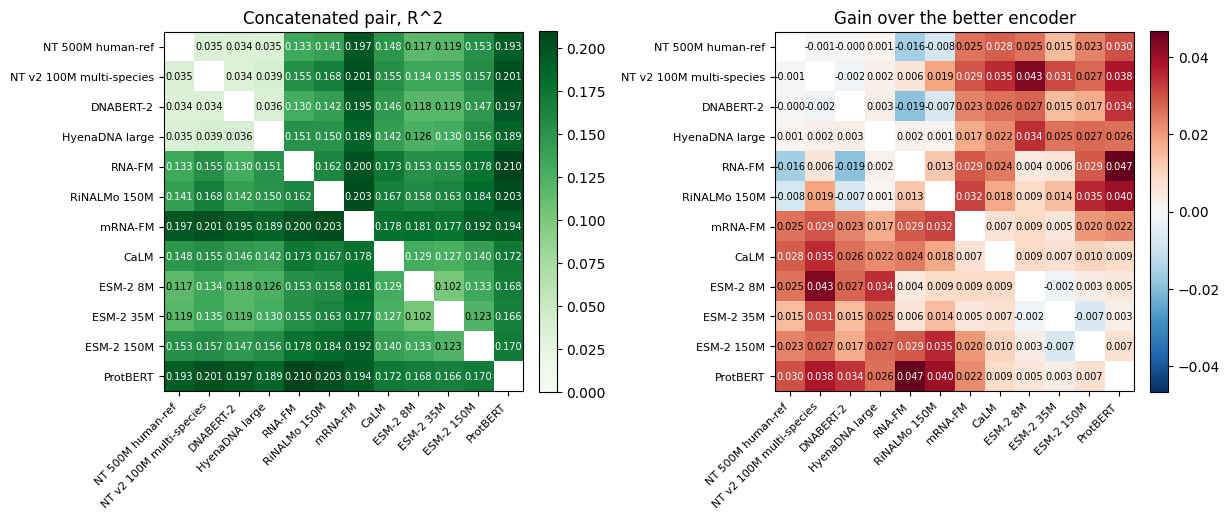

In [16]:
gtex_pair_concat, gtex_pair_gain = analysis.pairwise_concatenation_scores(
    GTEX_EMBEDDINGS, ENCODER_KEYS, gtex_labels, gtex_single_r2, groups=gtex_groups, seed=PROBE_SEED,
)
analysis.plot_matrices(
    {"Concatenated pair, R^2": gtex_pair_concat, "Gain over the better encoder": gtex_pair_gain},
    LABELS, diverging={"Gain over the better encoder"}, fmt="{:.3f}",
)

In [17]:
show_source(analysis.pairwise_assignment_gains, full=SHOW_IMPLEMENTATION)


Implementation: [`analysis.pairwise_assignment_gains` (line 172)](shared_code/analysis.py#L172)

In [18]:
gtex_pair_assignment_gains = analysis.pairwise_assignment_gains(
    GTEX_EMBEDDINGS, ENCODER_KEYS, gtex_labels, gtex_groups, n_assignments=N_FOLD_ASSIGNMENTS,
)

gtex_gain_rows = []
for a, b in PAIRS:
    gain = gtex_pair_assignment_gains[a, b]
    gtex_gain_rows.append({
        "pair": f"{LABELS[a]} + {LABELS[b]}",
        "comparison": f"within {MODALITY[a]}" if MODALITY[a] == MODALITY[b] else "across modalities",
        "pinned gain": gtex_pair_gain.loc[a, b],
        "mean gain": gain.mean(),
        "min gain": gain.min(),
        "max gain": gain.max(),
        "assignments with a gain": int((gain > 0).sum()),
    })
gtex_pair_gains = pd.DataFrame(gtex_gain_rows).set_index("pair").sort_values("mean gain", ascending=False)
gtex_pair_gains.round(3)

,comparison,pinned gain,mean gain,min gain,max gain,assignments with a gain
pair,,,,,,
RNA-FM + ProtBERT,across modalities,0.047,0.045,0.037,0.054,10
RiNALMo 150M + ESM-2 150M,across modalities,0.035,0.043,0.031,0.056,10
RiNALMo 150M + ProtBERT,across modalities,0.040,0.042,0.036,0.051,10
RNA-FM + ESM-2 150M,across modalities,0.029,0.041,0.034,0.058,10
DNABERT-2 + ProtBERT,across modalities,0.034,0.041,0.035,0.054,10
...,...,...,...,...,...,...
NT v2 100M multi-species + DNABERT-2,within DNA,-0.002,-0.002,-0.004,0.000,1
NT 500M human-ref + DNABERT-2,within DNA,-0.000,-0.004,-0.007,-0.001,0
DNABERT-2 + RNA-FM,across modalities,-0.019,-0.005,-0.018,0.006,3


In [19]:
gtex_group_sets = {f"All {m} encoders": [k for k in ENCODER_KEYS if MODALITY[k] == m] for m in ("DNA", "RNA", "protein")}
gtex_group_sets["One per modality: " + ", ".join(LABELS[k] for k in REFERENCE_KEYS)] = REFERENCE_KEYS
gtex_group_sets["All encoders"] = ENCODER_KEYS

gtex_group_probes = analysis.probe_table(
    {name: analysis.concatenate_embeddings(GTEX_EMBEDDINGS, keys) for name, keys in gtex_group_sets.items()},
    {"Expression": gtex_labels}, groups=gtex_groups, n_assignments=N_FOLD_ASSIGNMENTS, seed=PROBE_SEED,
)
gtex_group_probes["best member alone"] = [max(gtex_single_r2[k] for k in keys) for keys in gtex_group_sets.values()]
gtex_group_probes["difference"] = gtex_group_probes["Expression R2"] - gtex_group_probes["best member alone"]
gtex_group_probes.round(3)

,Expression R2,Expression SD,"Expression R2, 10 assignments","Expression SD, 10 assignments",best member alone,difference
encoder,,,,,,
All DNA encoders,0.035,0.033,0.045,0.008,0.036,-0.001
All RNA encoders,0.216,0.051,0.222,0.007,0.172,0.044
All protein encoders,0.165,0.034,0.174,0.012,0.163,0.002
"One per modality: NT 500M human-ref, RNA-FM, ESM-2 35M",0.157,0.042,0.172,0.013,0.149,0.008
All encoders,0.239,0.051,0.241,0.010,0.172,0.068


**Results.** On the pinned folds the best pair, RNA-FM with ProtBERT, reaches $R^2$ 0.210, and 57 of the 66 pairs exceed the better of their two encoders, by up to 0.047. Over the further fold assignments, 47 pairs gain under every assignment. The ten largest mean gains:

| Pair | Mean gain | Range of gains |
|---|---:|---:|
| RNA-FM + ProtBERT | $+0.045$ | $+0.037$ to $+0.054$ |
| RiNALMo 150M + ESM-2 150M | $+0.043$ | $+0.031$ to $+0.056$ |
| RiNALMo 150M + ProtBERT | $+0.042$ | $+0.036$ to $+0.051$ |
| RNA-FM + ESM-2 150M | $+0.041$ | $+0.034$ to $+0.058$ |
| DNABERT-2 + ProtBERT | $+0.041$ | $+0.035$ to $+0.054$ |
| NT v2 100M multi-species + ProtBERT | $+0.038$ | $+0.032$ to $+0.046$ |
| NT v2 100M multi-species + CaLM | $+0.034$ | $+0.028$ to $+0.043$ |
| NT v2 100M multi-species + ESM-2 8M | $+0.034$ | $+0.023$ to $+0.043$ |
| DNABERT-2 + CaLM | $+0.034$ | $+0.024$ to $+0.045$ |
| DNABERT-2 + ESM-2 8M | $+0.034$ | $+0.017$ to $+0.050$ |

| Group of pairs | Pairs gaining under all ten assignments |
|---|---:|
| DNA with protein | 16 of 16 |
| DNA with mRNA-FM or CaLM | 8 of 8 |
| DNA with RNA-FM or RiNALMo | 0 of 8 |
| RNA-FM or RiNALMo with protein | 8 of 8 |
| mRNA-FM or CaLM with protein | 6 of 8 |
| Within RNA | 5 of 6 |
| Within protein | 2 of 6 |
| Within DNA | 2 of 6 |

Larger concatenations:

| Combination | $R^2$, pinned (fold SD) | $R^2$, further assignments | Best member alone, pinned | Difference, pinned |
|---|---:|---:|---:|---:|
| All DNA encoders | 0.035 (0.033) | 0.045 | 0.036 | $-0.001$ |
| All RNA encoders | 0.216 (0.051) | 0.222 | 0.172 | $+0.044$ |
| All protein encoders | 0.165 (0.034) | 0.174 | 0.163 | $+0.002$ |
| One per modality (NT 500M human-ref, RNA-FM, ESM-2 35M) | 0.157 (0.042) | 0.172 | 0.149 | $+0.008$ |
| All encoders | 0.239 (0.051) | 0.241 | 0.172 | $+0.068$ |

**Interpretation.** Concatenation helps far more broadly than on the stability data, where every input was the same sequence. Every DNA encoder gains with every protein and codon-level encoder under all ten assignments, by 0.013 to 0.041 on average, even though the DNA window alone predicts little: the region around the start site carries information the coding sequence and protein lack. The exception is DNA with RNA-FM or RiNALMo, which gains inconsistently; those two encoders read the first 1,022 nucleotides of the transcript, which the downstream half of the DNA window also contains, so the two inputs partly overlap. That is a consistent explanation, not a tested one. The transcript-reading and coding-sequence-reading RNA encoders also complement each other, and all four RNA encoders together reach 0.216, 0.044 above mRNA-FM alone. Pairs within DNA or within protein gain little.

All twelve encoders together reach 0.239 on the pinned folds and 0.241 over the further assignments, the level of the four [length features](#Length-and-composition-baselines) alone (0.242). Combining distinct inputs adds information, but the frozen pooled embeddings together still carry about as much linearly accessible expression signal as transcript lengths do.

### GTEx published-split comparison

IsoFormer trains on its published train split and reports $R^2$ and the Spearman correlation on its test split, each averaged over tissues (Table 2). This comparison fits the probe once on the pilot's train half with `analysis.fit_predict` and scores its test half, whose genes never occur in the train half. It reports each encoder alone and the combinations of IsoFormer's Table 2. `ISOFORMER_DNA` and `ISOFORMER_PROTEIN` are the registry's closest matches to IsoFormer's DNA and protein encoders. IsoFormer also applies Nucleotide Transformer v2 to the transcript; no registry encoder does that, so each RNA encoder takes the RNA role in turn.

**Published values for reference.** IsoFormer, Table 2, mean over tissues ($R^2$ / Spearman): DNA only 0.13 / 0.43; RNA only 0.36 / 0.61; protein only 0.20 / 0.46; DNA and protein 0.28 / 0.52; DNA and RNA 0.39 / 0.64; DNA, RNA, and protein 0.43 / 0.65.

These values are not directly comparable with the table below. IsoFormer trains its encoders and a cross-attention aggregation end to end on a training split of about 160,000 transcripts, 82,000 of them protein-coding, reads 12,282 nucleotides of DNA, and applies Nucleotide Transformer to the transcript. Here the encoders stay frozen, a linear probe is fit on about 1,000 mean-pooled training embeddings, and the DNA window is 6,000 nucleotides. The comparison shows whether the frozen embeddings reproduce IsoFormer's ordering of modalities, not which method is better.

In [20]:
def gtex_published_split_scores(keys):
    """Fit the probe on the train half and return test-half R^2 and Spearman, averaged over tissues."""
    predicted = analysis.fit_predict(
        np.hstack([GTEX_EMBEDDINGS[k] for k in keys]), gtex_labels, np.hstack([GTEX_TEST_EMBEDDINGS[k] for k in keys])
    )
    measured = gtex_test.labels
    return {
        "R2, mean over tissues": r2_score(measured, predicted),
        "Spearman, mean over tissues": np.mean(
            [spearmanr(predicted[:, t], measured[:, t])[0] for t in range(measured.shape[1])]
        ),
    }


gtex_published_sets = {LABELS[k]: [k] for k in ENCODER_KEYS}
gtex_published_sets[f"DNA + protein ({LABELS[ISOFORMER_DNA]}, {LABELS[ISOFORMER_PROTEIN]})"] = [ISOFORMER_DNA, ISOFORMER_PROTEIN]
for r in [k for k in ENCODER_KEYS if MODALITY[k] == "RNA"]:
    gtex_published_sets[f"DNA + RNA ({LABELS[r]})"] = [ISOFORMER_DNA, r]
    gtex_published_sets[f"DNA + RNA + protein ({LABELS[r]})"] = [ISOFORMER_DNA, r, ISOFORMER_PROTEIN]
gtex_published_sets["All encoders"] = ENCODER_KEYS

pd.DataFrame({name: gtex_published_split_scores(keys) for name, keys in gtex_published_sets.items()}).T.round(3)

,"R2, mean over tissues","Spearman, mean over tissues"
NT 500M human-ref,0.051,0.242
NT v2 100M multi-species,0.054,0.249
DNABERT-2,0.034,0.212
HyenaDNA large,0.036,0.210
RNA-FM,0.151,0.396
RiNALMo 150M,0.150,0.404
mRNA-FM,0.204,0.452
CaLM,0.172,0.411
ESM-2 8M,0.113,0.333
ESM-2 35M,0.149,0.396


**Results.** Fit on the 999 train transcripts and scored on the 996 test transcripts, averaged over tissues:

| Encoders | $R^2$ | Spearman |
|---|---:|---:|
| NT 500M human-ref | 0.051 | 0.242 |
| NT v2 100M multi-species | 0.054 | 0.249 |
| DNABERT-2 | 0.034 | 0.212 |
| HyenaDNA large | 0.036 | 0.210 |
| RNA-FM | 0.151 | 0.396 |
| RiNALMo 150M | 0.150 | 0.404 |
| mRNA-FM | 0.204 | 0.452 |
| CaLM | 0.172 | 0.411 |
| ESM-2 8M | 0.113 | 0.333 |
| ESM-2 35M | 0.149 | 0.396 |
| ESM-2 150M | 0.179 | 0.423 |
| ProtBERT | 0.200 | 0.447 |
| DNA + protein: NT v2 100M, ESM-2 150M | 0.206 | 0.451 |
| DNA + RNA: NT v2 100M, RNA-FM | 0.173 | 0.432 |
| DNA + RNA + protein, with RNA-FM | 0.232 | 0.484 |
| DNA + RNA: NT v2 100M, RiNALMo 150M | 0.163 | 0.425 |
| DNA + RNA + protein, with RiNALMo 150M | 0.229 | 0.481 |
| DNA + RNA: NT v2 100M, mRNA-FM | 0.235 | 0.488 |
| DNA + RNA + protein, with mRNA-FM | 0.249 | 0.499 |
| DNA + RNA: NT v2 100M, CaLM | 0.198 | 0.445 |
| DNA + RNA + protein, with CaLM | 0.216 | 0.461 |
| All encoders | 0.269 | 0.522 |

**Interpretation.** The frozen embeddings reproduce IsoFormer's ordering in part. DNA alone is weakest, as in IsoFormer (0.034 to 0.054 here, 0.13 there). Protein alone with ESM-2 150M, IsoFormer's protein encoder, comes close to the published value: 0.179 against 0.20 in $R^2$ and 0.423 against 0.46 in Spearman. RNA alone falls furthest short, 0.150 to 0.204 against 0.36, which fits IsoFormer's design: it fine-tunes Nucleotide Transformer on the transcript, while no frozen RNA encoder here was trained for that role.

Adding modalities helps in the same order as in IsoFormer. With RNA-FM as the RNA encoder, adding the DNA window raises $R^2$ from 0.151 to 0.173, and adding ESM-2 150M raises it to 0.232; with mRNA-FM the three-modality set reaches 0.249, and all twelve encoders 0.269 (Spearman 0.522). IsoFormer's trained model starts higher and reaches 0.43, so frozen pooled embeddings with a linear probe recover about half of IsoFormer's three-modality $R^2$ (0.216 to 0.249 with one encoder per modality), trained on about 1% as many transcripts.

The [length baseline](#Length-and-composition-baselines) reaches 0.24 under cross-validation on the train half, close to the three-modality sets here. This comparison does not include it, so these values do not show how much the embeddings add beyond transcript lengths.

---

## GTEx Track B: Cross-modal geometry

The metrics follow the [CKA](../docs/methods/representation-comparison.md#final-layer-representation-similarity-linear-cka), [neighborhood](../docs/methods/representation-comparison.md#neighborhood-overlap-across-representations), and [CCA/retrieval](../docs/methods/representation-comparison.md#canonical-correlation-and-cross-modal-retrieval) procedures: linear CKA, mutual $k$-nearest-neighbor overlap with $k=10$, and CCA with retrieval on a held-out 30% of transcripts. `splits.grouped_holdout_split` assigns whole genes to the training or test side, so transcripts of one gene never straddle it.

### Linear CKA and neighborhood overlap on GTEx

Mutual k-NN chance for k = 10 among 999 rows: about 0.0100


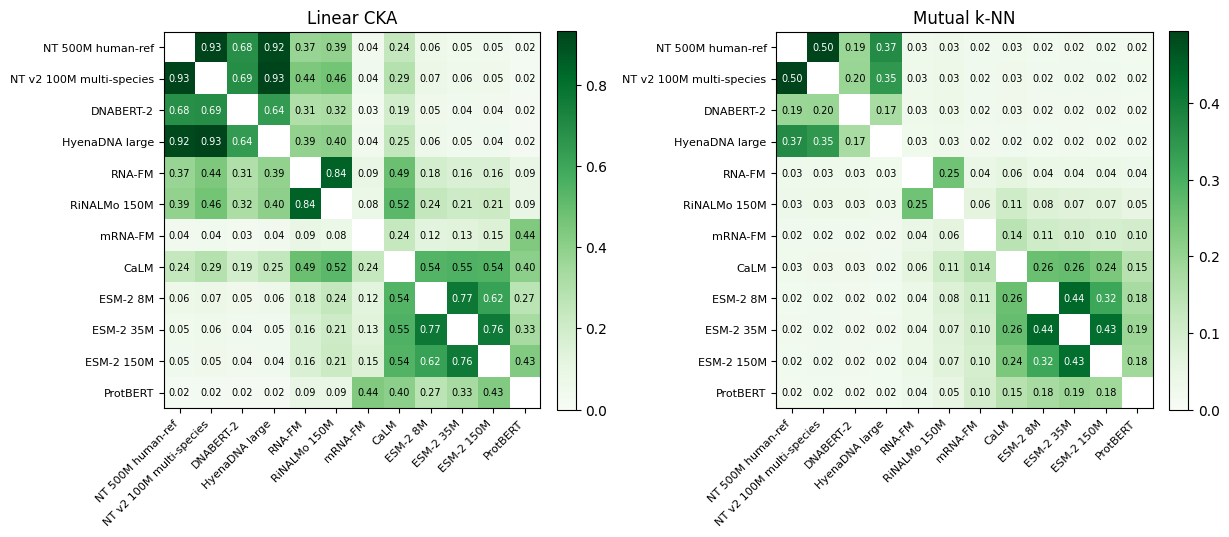

In [21]:
gtex_similarity = {
    "Linear CKA": analysis.pairwise_matrix(ENCODER_KEYS, lambda a, b: analysis.linear_cka(GTEX_EMBEDDINGS[a], GTEX_EMBEDDINGS[b])),
    "Mutual k-NN": analysis.pairwise_matrix(
        ENCODER_KEYS, lambda a, b: analysis.mutual_knn_alignment(GTEX_EMBEDDINGS[a], GTEX_EMBEDDINGS[b], k=10)
    ),
}
print(f"Mutual k-NN chance for k = 10 among {len(gtex_groups)} rows: about {10 / (len(gtex_groups) - 1):.4f}")
analysis.plot_matrices(gtex_similarity, LABELS, fmt="{:.2f}")

**Results.** Chance for mutual $k$-NN is about 0.0100.

| Group of pairs | Linear CKA | Mutual $k$-NN |
|---|---:|---:|
| Within ESM-2 | 0.618 to 0.770 | 0.32 to 0.44 |
| ProtBERT with ESM-2 | 0.267 to 0.427 | 0.18 to 0.19 |
| Within DNA | 0.638 to 0.933 | 0.17 to 0.49 |
| RNA-FM with RiNALMo | 0.845 | 0.25 |
| mRNA-FM with CaLM | 0.238 | 0.15 |
| DNA with RNA-FM or RiNALMo | 0.305 to 0.464 | 0.03 |
| DNA with mRNA-FM | 0.030 to 0.043 | 0.02 |
| DNA with CaLM | 0.190 to 0.288 | 0.02 to 0.03 |
| DNA with protein | 0.019 to 0.071 | 0.02 |
| RNA-FM or RiNALMo with mRNA-FM | 0.079 to 0.088 | 0.04 to 0.06 |
| RNA-FM or RiNALMo with CaLM | 0.487 to 0.524 | 0.06 to 0.11 |
| RNA-FM or RiNALMo with protein | 0.089 to 0.241 | 0.04 to 0.08 |
| mRNA-FM with protein | 0.121 to 0.437 | 0.10 to 0.11 |
| CaLM with protein | 0.404 to 0.551 | 0.15 to 0.26 |

**Interpretation.** The DNA encoders now agree with each other much more than on the stability data (0.638 to 0.933, with Nucleotide Transformer 500M, Nucleotide Transformer v2, and HyenaDNA at 0.915 to 0.933), and with everything else much less. Their neighborhoods overlap with those of any RNA or protein encoder at only 1.7 to 3.5 times chance. The DNA window and the gene's transcript and protein are different sequences, so this is the expected picture for distinct inputs. CKA between a DNA encoder and RNA-FM or RiNALMo (0.305 to 0.464) is higher than with the protein encoders, which fits the overlap between the window's downstream half and the transcript start, but their neighborhoods barely overlap.

Among the encoders that read coding information, the stability-data pattern repeats: the ESM-2 models agree most, CaLM agrees with the protein encoders (0.404 to 0.551) and with RNA-FM and RiNALMo, and mRNA-FM agrees little with anything except ProtBERT (0.437).

### Canonical correlation and retrieval on GTEx

Use the [CCA and retrieval walkthrough](../docs/methods/representation-comparison.md#canonical-correlation-and-cross-modal-retrieval) for the transformations and Recall@1 definition. Here the grouped split keeps transcripts of the same gene together, rather than grouping exact stability-sequence strings.


**Reading the saved retrieval heatmap.** Each pair measures the earlier encoder in `ENCODER_KEYS` querying the later encoder. Both displayed halves repeat that one direction; they do not measure reverse retrieval or an average of directions.


680 training rows, 319 test rows; Recall@1 chance 0.0031.


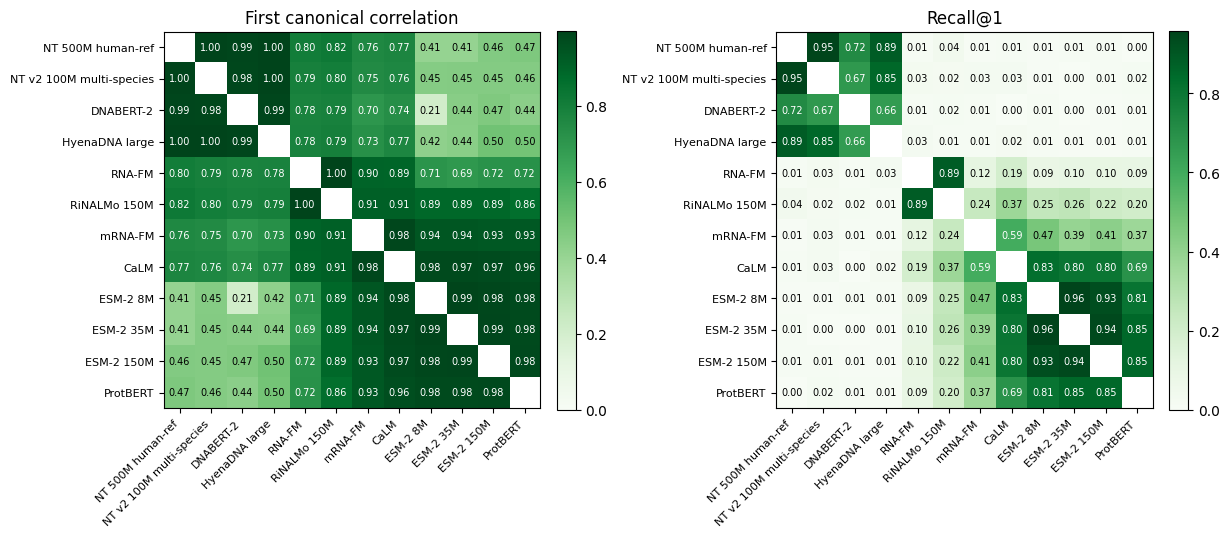

In [22]:
gtex_train_idx, gtex_test_idx = splits.grouped_holdout_split(gtex_groups, seed=SEED)
gtex_cca_results = {
    (a, b): analysis.cca_retrieval(GTEX_EMBEDDINGS[a], GTEX_EMBEDDINGS[b], gtex_train_idx, gtex_test_idx, SEED) for a, b in PAIRS
}
gtex_similarity["First canonical correlation"] = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: gtex_cca_results[(a, b)]["correlations"][0]
)
gtex_similarity["Recall@1"] = analysis.pairwise_matrix(ENCODER_KEYS, lambda a, b: gtex_cca_results[(a, b)]["recall"][1])
print(f"{len(gtex_train_idx)} training rows, {len(gtex_test_idx)} test rows; Recall@1 chance {1 / len(gtex_test_idx):.4f}.")
analysis.plot_matrices({name: gtex_similarity[name] for name in ["First canonical correlation", "Recall@1"]}, LABELS)

**Results.** CCA fitted on 680 transcripts and evaluated on 319 held-out transcripts, with every transcript of a gene on one side; Recall@1 chance is 0.0031.

| Group of pairs | First canonical correlation | Recall@1 |
|---|---:|---:|
| Within ESM-2 | 0.985 to 0.990 | 0.928 to 0.959 |
| ProtBERT with ESM-2 | 0.977 to 0.980 | 0.809 to 0.853 |
| Within DNA | 0.984 to 0.998 | 0.658 to 0.953 |
| RNA-FM with RiNALMo | 0.997 | 0.887 |
| mRNA-FM with CaLM | 0.983 | 0.592 |
| DNA with RNA-FM or RiNALMo | 0.779 to 0.819 | 0.009 to 0.041 |
| DNA with mRNA-FM or CaLM | 0.704 to 0.771 | 0.003 to 0.025 |
| DNA with protein | 0.210 to 0.505 | 0.000 to 0.016 |
| RNA-FM or RiNALMo with mRNA-FM or CaLM | 0.895 to 0.911 | 0.116 to 0.370 |
| RNA-FM or RiNALMo with protein | 0.695 to 0.887 | 0.088 to 0.263 |
| mRNA-FM with protein | 0.933 to 0.942 | 0.370 to 0.467 |
| CaLM with protein | 0.964 to 0.977 | 0.690 to 0.828 |

**Interpretation.** For pairs that include a DNA encoder and any other kind of encoder, the shared subspace is weak and retrieval is near chance: a transcript's own window is ranked first for at most 4.1% of test transcripts, and for at most 1.6% when the partner is a protein encoder, whose first canonical correlation with a DNA encoder is only 0.21 to 0.51. The encoders that read coding information correspond as they do on the stability data: CaLM finds its protein partner 69% to 83% of the time and mRNA-FM 37% to 47%. RNA-FM and RiNALMo, which read the transcript start rather than the whole coding sequence, find the protein partner only 9% to 26% of the time.

### Composition control on GTEx

The [composition-control procedure](../docs/methods/representation-comparison.md#composition-control) is repeated with GTEx's 92 composition features, including untranslated-region and genomic-DNA information. Each embedding is replaced by its residual after the all-row least-squares fit; CKA and retrieval are then repeated.

The printed $93/n$ reference counts features plus the intercept; it is a heuristic, not a calibrated null. Residualization includes all GTEx training transcripts used in this analysis, including those subsequently held out for the PCA/CCA comparison. Its preprocessing is therefore not fully held out, even though the composition fit uses no expression labels.


In [23]:
GTEX_RESIDUALS = {k: analysis.residualize(X, gtex_composition) for k, X in GTEX_EMBEDDINGS.items()}
print(f"Chance level for {gtex_composition.shape[1] + 1} predictors on {len(gtex_groups)} rows: "
      f"about {(gtex_composition.shape[1] + 1) / len(gtex_groups):.3f}")
pd.DataFrame(
    {"modality": [MODALITY[k] for k in ENCODER_KEYS],
     "share of variance explained by composition": [
         analysis.composition_share(GTEX_EMBEDDINGS[k], GTEX_RESIDUALS[k]) for k in ENCODER_KEYS]},
    index=[LABELS[k] for k in ENCODER_KEYS],
).round(3)

Chance level for 93 predictors on 999 rows: about 0.093


,modality,share of variance explained by composition
NT 500M human-ref,DNA,0.250
NT v2 100M multi-species,DNA,0.335
DNABERT-2,DNA,-0.002
HyenaDNA large,DNA,0.447
RNA-FM,RNA,0.355
RiNALMo 150M,RNA,0.373
mRNA-FM,RNA,0.131
CaLM,RNA,0.332
ESM-2 8M,protein,0.278
ESM-2 35M,protein,0.212


**Results.** Share of embedding variance explained by the 92 composition features, in sample, where 93 unrelated predictors would explain about 0.093:

| Encoder | Modality | $R^2_{\mathrm{comp}}$ |
|---|---|---:|
| NT 500M human-ref | DNA | 0.404 |
| NT v2 100M multi-species | DNA | 0.505 |
| DNABERT-2 | DNA | 0.326 |
| HyenaDNA large | DNA | 0.533 |
| RNA-FM | RNA | 0.502 |
| RiNALMo 150M | RNA | 0.502 |
| mRNA-FM | RNA | 0.305 |
| CaLM | RNA | 0.486 |
| ESM-2 8M | Protein | 0.443 |
| ESM-2 35M | Protein | 0.424 |
| ESM-2 150M | Protein | 0.442 |
| ProtBERT | Protein | 0.451 |

These features describe the coding sequence and the transcript in detail but the DNA window only through its GC fraction, so the control removes less of the DNA embeddings than of the others by construction.

c:\Users\dimar\anaconda3\Lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Users\dimar\anaconda3\Lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Users\dimar\anaconda3\Lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Users\dimar\anaconda3\Lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


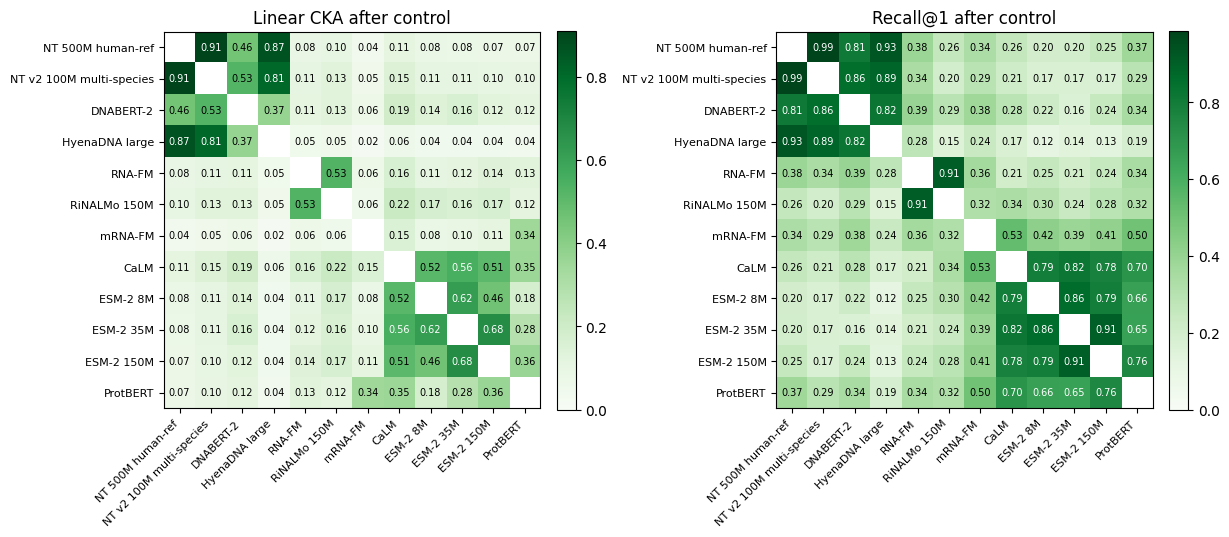

In [24]:
gtex_similarity["Linear CKA after control"] = analysis.pairwise_matrix(
    ENCODER_KEYS, lambda a, b: analysis.linear_cka(GTEX_RESIDUALS[a], GTEX_RESIDUALS[b])
)
gtex_similarity["Recall@1 after control"] = analysis.pairwise_matrix(
    ENCODER_KEYS,
    lambda a, b: analysis.cca_retrieval(GTEX_RESIDUALS[a], GTEX_RESIDUALS[b], gtex_train_idx, gtex_test_idx, SEED)["recall"][1],
)
analysis.plot_matrices(
    {name: gtex_similarity[name] for name in ["Linear CKA after control", "Recall@1 after control"]}, LABELS
)

**Results.** Agreement after removing the 92 composition features:

| Group of pairs | CKA after | Recall@1 after |
|---|---:|---:|
| Within ESM-2 | 0.458 to 0.665 | 0.639 to 0.824 |
| ProtBERT with ESM-2 | 0.111 to 0.226 | 0.467 to 0.624 |
| Within DNA | 0.441 to 0.931 | 0.618 to 0.947 |
| RNA-FM with RiNALMo | 0.488 | 0.809 |
| mRNA-FM with CaLM | 0.070 | 0.138 |
| DNA with any RNA or protein encoder | 0.004 to 0.057 | 0.000 to 0.022 |
| RNA-FM or RiNALMo with mRNA-FM or CaLM | 0.015 to 0.126 | 0.022 to 0.110 |
| RNA-FM or RiNALMo with protein | 0.035 to 0.109 | 0.016 to 0.085 |
| mRNA-FM with protein | 0.029 to 0.270 | 0.078 to 0.166 |
| CaLM with protein | 0.232 to 0.470 | 0.436 to 0.627 |

The `ConvergenceWarning` lines again mean that a few CCA fits reached scikit-learn's iteration limit.

**Interpretation.** The same groups keep their agreement as on the stability data: the ESM-2 models, ProtBERT with them, RNA-FM with RiNALMo, and CaLM with the protein encoders, whose Recall@1 stays at 44% to 63%. The DNA encoders keep their agreement with each other (CKA 0.441 to 0.931), but that says little: the 92 features describe the DNA window only through its GC fraction, so the control cannot remove the window's own composition. Agreement between a DNA encoder and any other encoder, already small, nearly vanishes.

### Summary of GTEx Track B metrics for every pair

In [25]:
gtex_track_b_summary = analysis.pair_table(gtex_similarity, PAIRS, LABELS, MODALITY)
gtex_track_b_summary["CKA reduction"] = 1 - gtex_track_b_summary["Linear CKA after control"] / gtex_track_b_summary["Linear CKA"]
gtex_track_b_summary.round(3)

,comparison,Linear CKA,Mutual k-NN,First canonical correlation,Recall@1,Linear CKA after control,Recall@1 after control,CKA reduction
pair,,,,,,,,
NT 500M human-ref / NT v2 100M multi-species,within DNA,0.933,0.495,0.998,0.953,0.913,0.987,0.022
NT 500M human-ref / DNABERT-2,within DNA,0.683,0.194,0.987,0.721,0.455,0.809,0.334
NT 500M human-ref / HyenaDNA large,within DNA,0.915,0.371,0.997,0.887,0.869,0.931,0.050
NT 500M human-ref / RNA-FM,across modalities,0.373,0.030,0.805,0.009,0.084,0.382,0.774
NT 500M human-ref / RiNALMo 150M,across modalities,0.390,0.032,0.819,0.041,0.099,0.257,0.746
...,...,...,...,...,...,...,...,...
ESM-2 8M / ESM-2 150M,within protein,0.618,0.319,0.985,0.928,0.461,0.793,0.254
ESM-2 8M / ProtBERT,within protein,0.267,0.175,0.977,0.809,0.177,0.658,0.336
ESM-2 35M / ESM-2 150M,within protein,0.764,0.427,0.989,0.944,0.680,0.906,0.110


### GTEx UMAP views

One UMAP layout per encoder, colored by modality, as in [Two-dimensional UMAP views](Stage1_stability.ipynb#Two-dimensional-UMAP-views). The layouts are exploratory and do not share coordinates.

c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\dimar\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for paralle

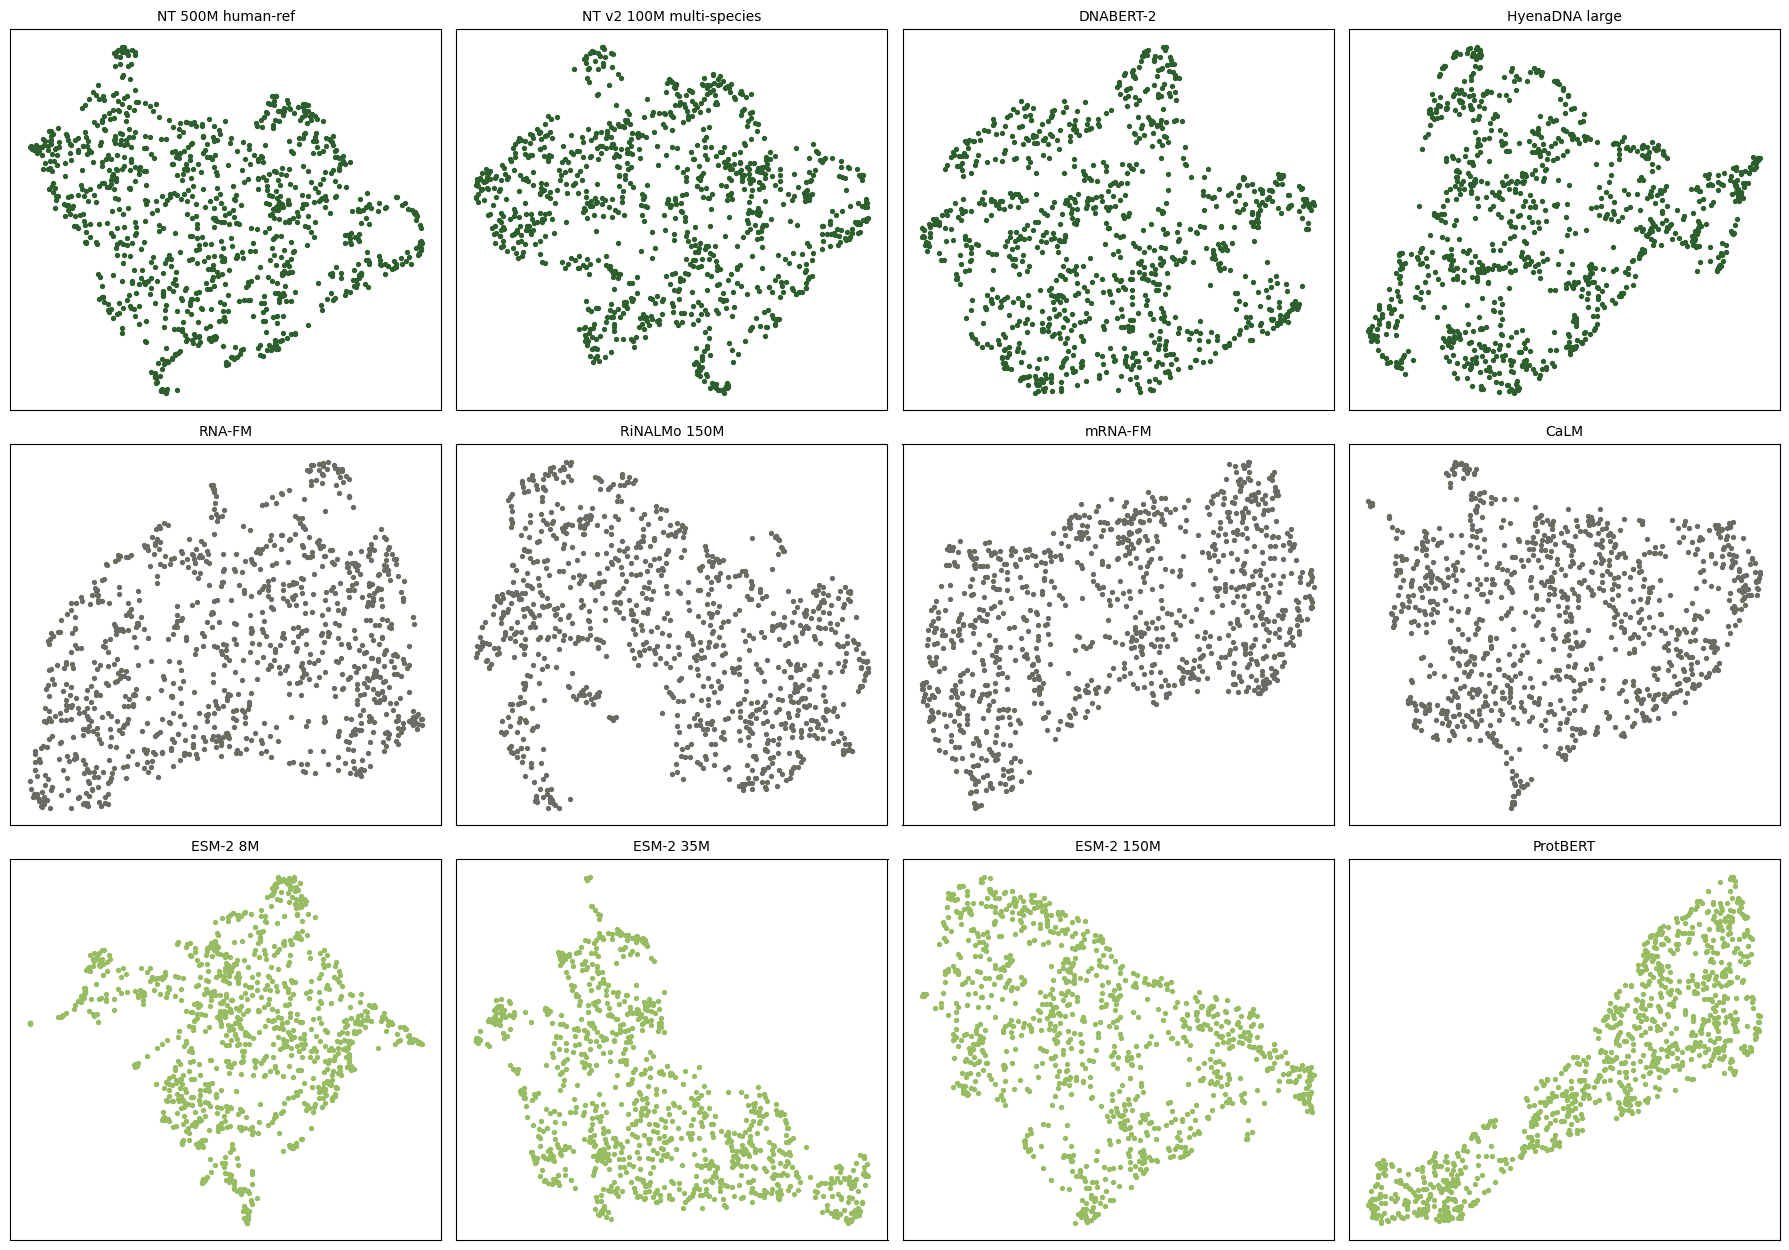

In [26]:
analysis.plot_umap(GTEX_EMBEDDINGS, LABELS, MODALITY, seed=SEED)

**Reading the plots.** Fewer layouts separate small, tightly packed groups than on the stability data; most show one continuous cloud. mRNA-FM again divides into two large lobes, and ProtBERT stretches into a band with a dense group at one end. Each layout is fitted separately and the plots are exploratory.

---

## GTEx Track C: Attention and diagnostics

### Attention at candidate patterns in 3' untranslated regions

This analysis uses annotated GTEx 3' untranslated regions, where the candidate ARE and m6A-associated patterns can be examined outside coding sequence. Each RNA encoder in `UTR_ATTENTION_ENCODERS` reads the 3' untranslated regions of the first `UTR_ATTENTION_N_ROWS` train transcripts that have one of at least `UTR_MIN_LEN` nucleotides, with token limits that cover at most 1,022 nucleotides; the expanded attention arrays determine the positions actually compared. The [attention summary and mapping](../docs/methods/attention-and-motifs.md#summarizing-attention-and-mapping-tokens-to-nucleotides), [pattern scan](../docs/methods/attention-and-motifs.md#scanning-candidate-rna-stability-associated-patterns), [per-sequence comparison](../docs/methods/attention-and-motifs.md#comparing-attention-at-matched-and-other-positions), and [permutation nulls](../docs/methods/attention-and-motifs.md#controlling-the-attention-test-for-position-and-codons) use the shared attention methods also used in the stability experiment. These are separate UTR attention extractions, not slices of earlier transcript attention. The second null exchanges labels among positions that share the same nonoverlapping three-nucleotide block identity and the same position within it, with blocks counted from the region's start. These are computational blocks, not annotated coding frames; the grouping keeps local sequence composition rather than biological codons.

In [27]:
utr_seqs = [u for u in gtex_train.column("utr3") if len(u) >= UTR_MIN_LEN][:UTR_ATTENTION_N_ROWS]
print(f"{len(utr_seqs)} 3' UTRs; median length {int(np.median([len(u) for u in utr_seqs]))} nucleotides.")

utr_profiles, utr_results = {}, {}
for key in UTR_ATTENTION_ENCODERS:
    utr_profiles[key] = embeddings.attention_profiles(encoders.ENCODERS[key], utr_seqs, DEVICE)
    utr_results[key] = analysis.attention_motif_tests(utr_profiles[key], utr_seqs)

analysis.attention_summary(utr_results, LABELS, sequences.STABILITY_MOTIFS).round(4)

100 3' UTRs; median length 770 nucleotides.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] RnaFmModel LOAD REPORT from: multimolecule/rnafm
Key                                 | Status     | 
------------------------------------+------------+-
ss_head.decoder.weight              | UNEXPECTED | 
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
ss_head.decoder.bias                | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
lm_head.transform.dense.bias        | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

[transformers] RiNALMoModel LOAD REPORT from: multimolecule/rinalmo-mega
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.transform.layer_norm.bias   | UNEXPECTED | 
lm_head.transform.dense.weight      | UNEXPECTED | 
lm_head.decoder.weight              | UNEXPECTED | 
lm_head.bias                        | UNEXPECTED | 
lm_head.transform.layer_norm.weight | UNEXPECTED | 
lm_head.transform.dense.bias        | UNEXPECTED | 
pooler.dense.bias                   | MISSING    | 
pooler.dense.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


sequences with hits  \
encoder      pattern                                    
RNA-FM       All patterns pooled                  100   
             ARE_pentamer                          49   
             ARE_nonamer                            2   
             m6A_DRACH                             98   
RiNALMo 150M All patterns pooled                  100   
             ARE_pentamer                          49   
             ARE_nonamer                            2   
             m6A_DRACH                             98   

                                  fraction with nominal p < 0.05  mean gap  
encoder      pattern                                                        
RNA-FM       All patterns pooled                          0.0700    0.0005  
             ARE_pentamer                                 0.1020   -0.0101  
             ARE_nonamer                                  0.0000   -0.0058  
             m6A_DRACH                                    0.0816    0.0017  
RiNALMo 150M All patterns pooled                          0.0600    0.0003  
             ARE_pentamer                                 0.3061    0.0291  
             ARE_nonamer                                  0.5000    0.0017  
             m6A_DRACH                                    0.0510   -0.0049

**Results.** The first 100 train transcripts with a 3' untranslated region of at least 50 nucleotides; their median length is 770 nucleotides.

| Encoder | Pattern | Sequences with hits | Fraction with nominal $p<0.05$ | Mean gap |
|---|---|---:|---:|---:|
| RNA-FM | All patterns pooled | 100 | 0.07 | $+0.0005$ |
| RNA-FM | ARE pentamer | 49 | 0.10 | $-0.0101$ |
| RNA-FM | ARE nonamer | 2 | 0.00 | $-0.0058$ |
| RNA-FM | m6A DRACH | 98 | 0.08 | $+0.0017$ |
| RiNALMo 150M | All patterns pooled | 100 | 0.06 | $+0.0003$ |
| RiNALMo 150M | ARE pentamer | 49 | 0.31 | $+0.0291$ |
| RiNALMo 150M | ARE nonamer | 2 | 0.50 | $+0.0017$ |
| RiNALMo 150M | m6A DRACH | 98 | 0.05 | $-0.0049$ |

In [28]:
gtex_null_rows = []
for key, profiles in utr_profiles.items():
    for motif in [None, *sequences.STABILITY_MOTIFS]:
        for strata, kept in (("position", "position"), ("codon", "three-nucleotide context")):
            result = analysis.motif_permutation_test(
                profiles, utr_seqs, motif=motif, strata=strata,
                n_permutations=ATTENTION_NULL_PERMUTATIONS, seed=SEED,
            )
            if result is not None:
                gtex_null_rows.append({
                    "encoder": LABELS[key], "pattern": motif or "All patterns pooled", "null keeps": kept, **result,
                })
pd.DataFrame(gtex_null_rows).set_index(["encoder", "pattern", "null keeps"]).round(4)

sequences  \
encoder      pattern             null keeps                            
RNA-FM       All patterns pooled position                        100   
                                 three-nucleotide context        100   
             ARE_pentamer        position                         49   
                                 three-nucleotide context         49   
             ARE_nonamer         position                          2   
                                 three-nucleotide context          2   
             m6A_DRACH           position                         98   
                                 three-nucleotide context         98   
RiNALMo 150M All patterns pooled position                        100   
                                 three-nucleotide context        100   
             ARE_pentamer        position                         49   
                                 three-nucleotide context         49   
             ARE_nonamer         position                          2   
                                 three-nucleotide context          2   
             m6A_DRACH           position                         98   
                                 three-nucleotide context         98   

                                                           observed gap  \
encoder      pattern             null keeps                               
RNA-FM       All patterns pooled position                        0.0005   
                                 three-nucleotide context        0.0005   
             ARE_pentamer        position                       -0.0101   
                                 three-nucleotide context       -0.0101   
             ARE_nonamer         position                       -0.0058   
                                 three-nucleotide context       -0.0058   
             m6A_DRACH           position                        0.0017   
                                 three-nucleotide context        0.0017   
RiNALMo 150M All patterns pooled position                        0.0003   
                                 three-nucleotide context        0.0003   
             ARE_pentamer        position                        0.0291   
                                 three-nucleotide context        0.0291   
             ARE_nonamer         position                        0.0017   
                                 three-nucleotide context        0.0017   
             m6A_DRACH           position                       -0.0049   
                                 three-nucleotide context       -0.0049   

                                                           null gap  \
encoder      pattern             null keeps                           
RNA-FM       All patterns pooled position                   -0.0012   
                                 three-nucleotide context    0.0001   
             ARE_pentamer        position                   -0.0012   
                                 three-nucleotide context   -0.0047   
             ARE_nonamer         position                   -0.0038   
                                 three-nucleotide context   -0.0018   
             m6A_DRACH           position                   -0.0008   
                                 three-nucleotide context    0.0003   
RiNALMo 150M All patterns pooled position                    0.0004   
                                 three-nucleotide context    0.0000   
             ARE_pentamer        position                    0.0039   
                                 three-nucleotide context    0.0255   
             ARE_nonamer         position                   -0.0160   
                                 three-nucleotide context    0.0091   
             m6A_DRACH           position                   -0.0000   
                                 three-nucleotide context   -0.0040   

                                                           excess gap  \
encoder      pattern             null keeps                

**Results.** One row has a permutation $p$ below 0.05: RiNALMo's ARE pentamer gap under the position null, with an excess gap of $+0.0252$ ($p = 0.002$). Under the three-nucleotide-context null the same gap falls to an excess of $+0.0037$ ($p = 0.164$). Every RNA-FM row has $p$ of at least 0.158, and the remaining RiNALMo rows at least 0.229.

**Interpretation.** In 3' untranslated regions, where AU-rich elements and m6A sites act, RNA-FM shows no association between final-layer attention and either pattern. RiNALMo gives ARE pentamers more attention in 15 of 49 regions, and the gap survives the position null but not the three-nucleotide-context null: RiNALMo attends to the U-rich trinucleotides that make up an AUUUA pentamer wherever they occur, not to the pentamer as a unit. This repeats its result on coding sequence, where codon context explained the same gap. The ARE nonamer occurs in only two regions, too few to test.

---

### Alignment, prediction error, and representational similarity on GTEx

The [alignment/error diagnostic](../docs/methods/representation-comparison.md#sample-level-alignment-and-prediction-error) relates each held-out transcript's CCA cosine similarity to out-of-fold absolute error for its mean expression. CCA's split groups by gene, but this diagnostic's later regression uses ungrouped row-wise folds inside that CCA test subset.

[RSA and its Mantel procedure](../docs/methods/representation-comparison.md#representational-similarity-analysis) compare all matched GTEx training-transcript embeddings. The permutation code shuffles individual rows, not gene groups; its significance interpretation depends on whether that exchangeability assumption is justified. Both diagnostics use existing embeddings and retain the interpretation limits of [Run and interpret the alignment diagnostics](Stage1_stability.ipynb#Run-and-interpret-the-alignment-diagnostics).


In [29]:
gtex_diagnostic_rows = []
for a, b in PAIRS:
    a_test_c, b_test_c = gtex_cca_results[(a, b)]["test_coords"]
    association = analysis.alignment_error_association(a_test_c, b_test_c, mean_expression[gtex_test_idx], seed=SEED)
    rsa, rsa_p = analysis.compute_rsa(GTEX_EMBEDDINGS[a], GTEX_EMBEDDINGS[b])
    gtex_diagnostic_rows.append({
        "pair": f"{LABELS[a]} / {LABELS[b]}",
        "comparison": f"within {MODALITY[a]}" if MODALITY[a] == MODALITY[b] else "across modalities",
        "alignment vs. error, Spearman rho": association["spearman"],
        "nominal p": association["p_value"],
        "RSA": rsa,
        "Mantel p": analysis.mantel_p_value(GTEX_EMBEDDINGS[a], GTEX_EMBEDDINGS[b], seed=SEED),
    })
print(f"Bonferroni threshold for {len(PAIRS)} pairs at 0.05: {0.05 / len(PAIRS):.4f}")
pd.DataFrame(gtex_diagnostic_rows).set_index("pair").round(4)

Bonferroni threshold for 66 pairs at 0.05: 0.0008


,comparison,"alignment vs. error, Spearman rho",nominal p,RSA,Mantel p
pair,,,,,
NT 500M human-ref / NT v2 100M multi-species,within DNA,-0.0251,0.6548,0.9329,0.002
NT 500M human-ref / DNABERT-2,within DNA,-0.1334,0.0171,0.7045,0.002
NT 500M human-ref / HyenaDNA large,within DNA,0.0161,0.7749,0.8787,0.002
NT 500M human-ref / RNA-FM,across modalities,-0.0201,0.7203,0.3078,0.002
NT 500M human-ref / RiNALMo 150M,across modalities,0.0182,0.7457,0.3053,0.002
...,...,...,...,...,...
ESM-2 8M / ESM-2 150M,within protein,-0.0114,0.8394,0.6381,0.002
ESM-2 8M / ProtBERT,within protein,-0.0735,0.1906,0.2038,0.002
ESM-2 35M / ESM-2 150M,within protein,-0.0079,0.8881,0.7685,0.002


**Results.** Alignment against prediction error uses the 319 CCA test transcripts and their mean expression over tissues; RSA uses all 999 train transcripts.

- **Alignment against error.** Spearman $\rho$ ranges from $-0.134$ to $+0.100$ across the 66 pairs. One pair, Nucleotide Transformer 500M with DNABERT-2, has a nominal $p$ below 0.05 (0.017); none is below the Bonferroni threshold of 0.0008.
- **RSA.** The Mantel $p$ is 0.002 for 55 pairs and 0.004 to 0.006 for four more. It is above 0.05 for mRNA-FM with every DNA encoder (0.160 to 0.258) and with every ESM-2 model (0.126 to 0.706).

| Group of pairs | RSA |
|---|---:|
| Within ESM-2 | 0.638 to 0.806 |
| ProtBERT with ESM-2 | 0.204 to 0.266 |
| Within DNA | 0.663 to 0.933 |
| RNA-FM with RiNALMo | 0.771 |
| mRNA-FM with CaLM | 0.082 |
| DNA with RNA-FM or RiNALMo | 0.240 to 0.351 |
| DNA with mRNA-FM or CaLM | 0.013 to 0.185 |
| DNA with protein | 0.038 to 0.096 |
| RNA-FM or RiNALMo with mRNA-FM or CaLM | 0.048 to 0.439 |
| RNA-FM or RiNALMo with protein | 0.098 to 0.271 |
| mRNA-FM with protein | $-0.013$ to 0.266 |
| CaLM with protein | 0.342 to 0.525 |

**Interpretation.** On a second dataset with distinct inputs, a transcript's per-sample alignment again has no detectable relationship with how accurately its expression is predicted. RSA ranks the pairs as CKA does, and mRNA-FM's distance structure is unrelated to that of the DNA encoders and the ESM-2 models, consistent with its isolated geometry on both datasets.

---

## Figure exports from completed results

These cells present the captured GTEx result state loaded by the figure settings as `GTEX_FIGURE_SNAPSHOT`. Their timestamp identifies that snapshot; the figures do not claim to reflect later changes in the live kernel. They do not load models, compute embeddings, refit probes or rerun the notebook. After a kernel restart, use `python Code/export_figures.py gtex` from the repository root to regenerate the exports from `docs/figures/gtex/results.json` without a notebook kernel. Alternatively, run the figure settings and this section to render the same snapshot interactively.

The snapshot preserves full-precision named result objects. The length and composition baseline scores survive only in the retained, three-decimal `Out[14]` table; their limited precision is explicit in the comparison and CSV. The baseline comparison uses the same pinned-fold score column for every row. Repeated-assignment means and pinned-fold means remain separate elsewhere. No new research statistic is fitted; the assignment mean and range summarize already-saved gains.

Each pair plot contains one point per encoder pair, with the complete 66-pair table exported. Retrieval follows the encoder registry direction, from the first listed encoder to the second. Composition residualization uses all 999 training-half rows before the later retrieval split, including its test rows. The 996-transcript published test half is not the retrieval test set in these panels. Figures export SVG, 300-dpi PNG, CSV and a manifest beside the complete pair and assignment tables.

In [ ]:
if "GTEX_FIGURE_SNAPSHOT" not in globals():
    raise RuntimeError(
        "GTEx figure snapshot required; no research was rerun. "
        "After a restart use: python Code/export_figures.py gtex"
    )
gtex_figure_required = {
    "dataset", "encoder_keys", "labels", "modality", "seed", "probe_seed",
    "n_assignments", "counts", "similarity", "pair_concat", "pair_gain",
    "pair_assignment_gains", "expression_probes", "group_probes", "baseline_probes", "baseline_provenance",
    "capture_utc", "notebook", "disk_notebook_sha256_at_capture",
    "sequence_order_sha256", "groups_order_sha256", "cell_history_checks",
}
if not isinstance(GTEX_FIGURE_SNAPSHOT, dict):
    raise TypeError("GTEX_FIGURE_SNAPSHOT must be the captured result dictionary.")
gtex_figure_missing = sorted(gtex_figure_required - GTEX_FIGURE_SNAPSHOT.keys())
if gtex_figure_missing:
    raise RuntimeError("Incomplete GTEx snapshot: " + ", ".join(gtex_figure_missing))
gtex_figure_source = GTEX_FIGURE_SNAPSHOT
if gtex_figure_source["dataset"] != "gtex_pilot":
    raise ValueError("These figure cells require the GTEx pilot snapshot.")
gtex_figure_counts = gtex_figure_source["counts"]
gtex_figure_keys = gtex_figure_source["encoder_keys"]
gtex_figure_labels = gtex_figure_source["labels"]
gtex_figure_modalities = gtex_figure_source["modality"]
gtex_figure_n_assignments = gtex_figure_source["n_assignments"]
if gtex_figure_source["baseline_provenance"]["decimal_places"] != 3:
    raise ValueError("This comparison expects the retained three-decimal baseline table.")


def gtex_figure_frame(value, index_name=None):
    frame = pd.DataFrame(value["data"], columns=value["columns"], index=value["index"])
    frame.index.name = index_name
    return frame


gtex_figure_metrics = {key: gtex_figure_frame(value) for key, value in gtex_figure_source["similarity"].items()}
gtex_figure_concat = gtex_figure_frame(gtex_figure_source["pair_concat"])
gtex_figure_gain = gtex_figure_frame(gtex_figure_source["pair_gain"])
gtex_figure_assignments = {(row["a"], row["b"]): np.asarray(row["values"], dtype=float)
                           for row in gtex_figure_source["pair_assignment_gains"]}
gtex_figure_pairs = pd.DataFrame([
    {
        "a": a, "b": b, "encoder_a": gtex_figure_labels[a], "encoder_b": gtex_figure_labels[b],
        "modality_a": gtex_figure_modalities[a], "modality_b": gtex_figure_modalities[b],
        **{metric: float(matrix.loc[a, b]) for metric, matrix in gtex_figure_metrics.items()},
        "pinned_concat_r2": float(gtex_figure_concat.loc[a, b]),
        "pinned_gain": float(gtex_figure_gain.loc[a, b]),
    }
    for a, b in itertools.combinations(gtex_figure_keys, 2)
])
for gtex_figure_pair, gtex_figure_values in gtex_figure_assignments.items():
    if len(gtex_figure_values) != gtex_figure_n_assignments or not np.isfinite(gtex_figure_values).all():
        raise ValueError(f"Invalid saved assignment gains for {gtex_figure_pair}.")
if set(gtex_figure_assignments) != set(itertools.combinations(gtex_figure_keys, 2)):
    raise ValueError("Saved assignment gains must cover every encoder pair exactly once.")

gtex_figure_manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(), "dataset": gtex_figure_source["dataset"],
    "snapshot_file": GTEX_FIGURE_SOURCE.name,
    "snapshot_sha256": hashlib.sha256(GTEX_FIGURE_SOURCE.read_bytes()).hexdigest(),
    "execution_basis": "Plot cells only, using the captured GTEx result dictionary; no research function rerun.",
    "capture_utc": gtex_figure_source["capture_utc"], "source_notebook": gtex_figure_source["notebook"],
    "source_notebook_sha256_at_capture": gtex_figure_source["disk_notebook_sha256_at_capture"],
    "sequence_order_sha256": gtex_figure_source["sequence_order_sha256"],
    "groups_order_sha256": gtex_figure_source["groups_order_sha256"],
    "counts": gtex_figure_counts, "seed": gtex_figure_source["seed"],
    "probe_seed": gtex_figure_source["probe_seed"],
    "further_assignment_seeds": list(range(gtex_figure_n_assignments)),
    "cell_history_matches": sum(row["matches_kernel_history"] for row in gtex_figure_source["cell_history_checks"]),
    "cell_history_total": len(gtex_figure_source["cell_history_checks"]),
    "producer_limit": "Input-history matches identify submitted code; they do not identify the producing run of reused embedding caches.",
    "source_versions": gtex_figure_source.get("versions", {}),
    "baseline_provenance": gtex_figure_source["baseline_provenance"],
    "colors": GTEX_FIGURE_COLORS, "figures": {}, "artifact_sha256": {},
    "complete_pair_tables": ["pair_metrics_all.csv", "assignment_gains_all.csv"],
    "limits": [
        "The baseline rows in figure 02 come from retained Out[14], already rounded to three decimals.",
        "Pinned fold means, repeated-assignment means, fold SD and assignment SD have distinct meanings.",
        "Pair retrieval is directional in encoder registry order, not a bidirectional average.",
        "Composition residualization fits all training-half rows before subsequent retrieval evaluation.",
        "Assignment ranges describe partition sensitivity, not confidence intervals.",
        "The 319 retrieval test rows are separate from the 996-transcript published test half.",
        "Pair scatterplots do not fit a trend or establish significance or causality.",
    ],
}


def gtex_figure_check_numeric(frame, name):
    if not np.isfinite(frame.select_dtypes(include=[np.number]).to_numpy()).all():
        raise ValueError(f"Non-finite values in {name}; export stopped.")


def gtex_figure_finish(fig, name, data, source_cells, notes):
    gtex_figure_check_numeric(data, name)
    fig.text(.025, .002, "Captured result state · " + gtex_figure_source["capture_utc"][:19].replace("T", " ") + " UTC", fontsize=9, color="#526577")
    data.to_csv(GTEX_FIGURE_DIR / f"{name}.csv", index=False, float_format="%.17g")
    for extension in ("svg", "png"):
        fig.savefig(GTEX_FIGURE_DIR / f"{name}.{extension}", dpi=300,
                    facecolor="white", bbox_inches="tight", pad_inches=.16)
    gtex_figure_manifest["figures"][name] = {
        "files": [f"{name}.{extension}" for extension in ("svg", "png", "csv")],
        "rows": len(data), "source_cells": source_cells, "notes": notes,
    }
    for filename in gtex_figure_manifest["complete_pair_tables"] + [
            filename for item in gtex_figure_manifest["figures"].values() for filename in item["files"]]:
        gtex_figure_manifest["artifact_sha256"][filename] = hashlib.sha256((GTEX_FIGURE_DIR / filename).read_bytes()).hexdigest()
    (GTEX_FIGURE_DIR / "manifest.json").write_text(json.dumps(gtex_figure_manifest, indent=2), encoding="utf-8")
    if plt.get_backend().lower() != "agg":
        plt.show()
    plt.close(fig)


def gtex_figure_pair_legend(fig, y=.835):
    handles = [Line2D([], [], marker="o", linestyle="none", markersize=8,
                      markerfacecolor=color, markeredgecolor=color, label=name)
               for name, color in GTEX_FIGURE_COLORS.items()]
    fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(.025, y),
               ncol=3, frameon=False, title="Pair marker: edge = first encoder; fill = second encoder",
               title_fontsize=11, fontsize=11)


GTEX_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
gtex_figure_check_numeric(gtex_figure_pairs, "pair_metrics_all")
gtex_figure_pairs.to_csv(GTEX_FIGURE_DIR / "pair_metrics_all.csv", index=False, float_format="%.17g")
pd.DataFrame([
    {"a": a, "b": b, "assignment_seed": seed, "gain": float(value)}
    for (a, b), values in gtex_figure_assignments.items() for seed, value in enumerate(values)
]).to_csv(GTEX_FIGURE_DIR / "assignment_gains_all.csv", index=False, float_format="%.17g")

### Expression probes across all encoders

These are the existing [expression probe results](#Expression-prediction-with-linear-probes) on the GTEx training half. Circles show the mean across ten further gene-grouped fold assignments; crosses show the pinned-fold mean. Each fold's score averages $R^2$ over 30 tissue targets. The two standard deviations remain separate CSV columns and are not drawn as uncertainty bars.

In [ ]:
def gtex_figure_draw_expression():
    gtex_figure_probes = gtex_figure_frame(gtex_figure_source["expression_probes"], "encoder")
    gtex_figure_probes = gtex_figure_probes.loc[[gtex_figure_labels[key] for key in gtex_figure_keys]].reset_index()
    gtex_figure_repeated_column = f"Expression R2, {gtex_figure_n_assignments} assignments"
    with plt.rc_context(GTEX_FIGURE_STYLE):
        fig, ax = plt.subplots(figsize=(12.5, 8.2))
        fig.subplots_adjust(left=.31, right=.95, bottom=.18, top=.76)
        fig.suptitle("GTEx expression prediction from frozen encoders", x=.025, y=.98, ha="left", fontsize=19, weight="bold")
        fig.text(.025, .885, f"{gtex_figure_counts['train']} training-half transcripts · {gtex_figure_counts['train_genes']} genes · {gtex_figure_counts['tissues']} tissue targets", fontsize=12)
        fig.text(.025, .825, f"● Mean across {gtex_figure_n_assignments} further assignments (seeds 0–{gtex_figure_n_assignments - 1})    × Pinned folds (seed {gtex_figure_source['probe_seed']})", fontsize=11)
        for row_index, row in gtex_figure_probes.iterrows():
            color = GTEX_FIGURE_COLORS[row.modality]
            mean = row[gtex_figure_repeated_column]
            ax.plot([row["Expression R2"], mean], [row_index] * 2, color="#BCC5CC", lw=1.5)
            ax.scatter(mean, row_index, s=75, color=color, zorder=3)
            ax.scatter(row["Expression R2"], row_index, s=60, marker="x", color="#283541", lw=1.8, zorder=4)
            ax.annotate(f"{mean:.3f}", (mean, row_index), xytext=(9, 0), textcoords="offset points", va="center", fontsize=11)
        ax.set_yticks(range(len(gtex_figure_probes)), gtex_figure_probes.encoder)
        ax.invert_yaxis()
        ax.set_xlim(0, .205)
        ax.set_xlabel("Mean gene-grouped probe R² · averaged over tissues")
        ax.tick_params(axis="y", length=0)
        ax.spines["left"].set_visible(False)
        ax.grid(axis="x", color="#E6E9EC", lw=.8)
        ax.set_axisbelow(True)
        for boundary in (3.5, 7.5):
            ax.axhline(boundary, color="#D2D8DD", lw=.8)
        fig.text(.025, .065, "DNA blue · RNA green · protein orange. No confidence intervals shown; fold and assignment SDs are distinct.", fontsize=11)
        gtex_figure_finish(fig, "01_all_encoder_expression_probes", gtex_figure_probes,
                           ["2b098a7f"], "Full-precision named probe table; repeated-assignment means and pinned-fold means are separate markers.")


gtex_figure_draw_expression()

### Baselines and concatenation on the same pinned folds

Compare the [length and composition baselines](#Length-and-composition-baselines) with the strongest single encoder in the pinned-fold table and the [concatenation of all encoders](#Expression-prediction-from-concatenated-embeddings). Every row uses `Expression R2`, the same gene-grouped pinned folds. The length and composition values come from retained `Out[14]`, already rounded to three decimals; encoder scores come from full-precision named tables. All labels display three decimals, so close values must not be interpreted as exactly equal. The best-single designation is selected on this table, not an independent model-selection result.

In [ ]:
def gtex_figure_draw_baselines():
    gtex_figure_baselines = gtex_figure_frame(gtex_figure_source["baseline_probes"])
    gtex_figure_single = gtex_figure_frame(gtex_figure_source["expression_probes"])
    gtex_figure_group = gtex_figure_frame(gtex_figure_source["group_probes"])
    gtex_figure_best_single = gtex_figure_single["Expression R2"].idxmax()
    gtex_figure_comparison = pd.DataFrame([
        {"representation": name, "pinned_mean_r2": float(gtex_figure_baselines.loc[name, "Expression R2"]),
         "precision": "retained Out[14], rounded to 3 decimals", "source": "1ec3fde2 / Out[14]",
         "color": "#526577"}
        for name in gtex_figure_baselines.index
    ] + [
        {"representation": f"Best single: {gtex_figure_best_single}",
         "pinned_mean_r2": float(gtex_figure_single.loc[gtex_figure_best_single, "Expression R2"]),
         "precision": "full-precision captured named result", "source": "2b098a7f / gtex_expression_probes",
         "color": GTEX_FIGURE_COLORS[gtex_figure_single.loc[gtex_figure_best_single, "modality"]]},
        {"representation": "All 12 encoders concatenated",
         "pinned_mean_r2": float(gtex_figure_group.loc["All encoders", "Expression R2"]),
         "precision": "full-precision captured named result", "source": "58dad62b / gtex_group_probes",
         "color": "#735AA5"},
    ])
    with plt.rc_context(GTEX_FIGURE_STYLE):
        fig, ax = plt.subplots(figsize=(12.5, 5.8))
        fig.subplots_adjust(left=.34, right=.95, bottom=.27, top=.70)
        fig.suptitle("GTEx baselines and encoder concatenation", x=.025, y=.98, ha="left", fontsize=19, weight="bold")
        fig.text(.025, .87, f"Same pinned gene-grouped folds (seed {gtex_figure_source['probe_seed']}) · {gtex_figure_counts['train']} transcripts · {gtex_figure_counts['tissues']} tissue targets", fontsize=12)
        for row_index, row in gtex_figure_comparison.iterrows():
            ax.barh(row_index, row.pinned_mean_r2, height=.50, color=row.color)
            ax.annotate(f"{row.pinned_mean_r2:.3f}", (row.pinned_mean_r2, row_index), xytext=(8, 0), textcoords="offset points", va="center", fontsize=12)
        ax.set_yticks(range(len(gtex_figure_comparison)), gtex_figure_comparison.representation)
        ax.invert_yaxis()
        ax.set_xlim(0, .285)
        ax.set_xlabel("Pinned mean probe R² · averaged over tissues")
        ax.tick_params(axis="y", length=0)
        ax.spines["left"].set_visible(False)
        ax.grid(axis="x", color="#E6E9EC", lw=.8)
        ax.set_axisbelow(True)
        fig.text(.025, .12, "Baseline inputs: retained Out[14], rounded to 3 decimals. Encoder inputs: full-precision named result tables.", fontsize=11)
        fig.text(.025, .055, "All labels show 3 decimals; nearby values are not exact ties. Best single is selected by this pinned-fold table.", fontsize=11)
        gtex_figure_finish(fig, "02_pinned_baselines_and_encoders", gtex_figure_comparison,
                           ["1ec3fde2", "2b098a7f", "58dad62b"], "Same pinned fold column throughout; baseline rows have only three-decimal retained precision; no uncertainty bars.")


gtex_figure_draw_baselines()

### Raw and composition-residual agreement across all pairs

Each panel contains all 66 encoder pairs, one point per pair. The horizontal value is the raw metric and the vertical value is its [composition-residual counterpart](#Composition-control-on-GTEx); the diagonal means no change. Marker edges and fills identify the first and second encoders' modalities. Retrieval follows registry order and uses a 680/319 gene-grouped split inside the training half. Residualization was fit on all 999 training-half rows before that split was evaluated.

In [ ]:
def gtex_figure_draw_controls():
    with plt.rc_context(GTEX_FIGURE_STYLE):
        fig, axes = plt.subplots(1, 2, figsize=(13.5, 7.8))
        fig.subplots_adjust(left=.085, right=.97, bottom=.19, top=.66, wspace=.28)
        fig.suptitle("GTEx composition control across all 66 encoder pairs", x=.025, y=.98, ha="left", fontsize=19, weight="bold")
        fig.text(.025, .90, f"One point = one pair · CKA: {gtex_figure_counts['train']} transcripts · retrieval: {gtex_figure_counts['cca_fit']} fit / {gtex_figure_counts['cca_test']} test", fontsize=12)
        gtex_figure_pair_legend(fig)
        for ax, (raw, controlled, title) in zip(axes, [
            ("Linear CKA", "Linear CKA after control", "Linear CKA"),
            ("Recall@1", "Recall@1 after control", "CCA Recall@1"),
        ]):
            ax.plot([0, 1], [0, 1], color="#87949F", ls="--", lw=1)
            for _, row in gtex_figure_pairs.iterrows():
                ax.scatter(row[raw], row[controlled], s=58,
                           facecolor=GTEX_FIGURE_COLORS[row.modality_b],
                           edgecolor=GTEX_FIGURE_COLORS[row.modality_a], lw=2, alpha=.9, zorder=3)
            ax.set(xlim=(-.025, 1.025), ylim=(-.025, 1.025), xlabel="Raw", ylabel="Composition residuals")
            ax.set_title(title, loc="left", pad=12)
            ax.grid(color="#E6E9EC", lw=.8)
            ax.set_axisbelow(True)
        fig.text(.025, .105, "Diagonal = unchanged metric. Retrieval direction: first encoder → second in registry order; all identities are in the CSV.", fontsize=10.5)
        fig.text(.025, .045, "Exploratory control: residualization fits all training-half rows, including later retrieval test rows.", fontsize=11)
        gtex_figure_finish(fig, "03_all_pairs_composition_control", gtex_figure_pairs,
                           ["3d7e618b", "573cf835", "9c177b94", "205ebbdc"], "All 66 pairs; raw x and residual y; directed retrieval; full training-half residual preprocessing.")


gtex_figure_draw_controls()

### Representation agreement and matched concatenation gain

Each point is one pair's mean [concatenation gain](#Expression-prediction-from-concatenated-embeddings) across the ten saved fold assignments; each line spans their minimum and maximum. Each saved gain subtracts the better single encoder on the same assignment. Both geometry and gains use raw representations. The ranges describe sensitivity to the partition, not confidence intervals. No fitted trend, significance test or causal relationship is added.

In [ ]:
def gtex_figure_draw_gains():
    gtex_figure_geometry_gain = gtex_figure_pairs.copy()
    for row_index, row in gtex_figure_geometry_gain.iterrows():
        values = gtex_figure_assignments[(row.a, row.b)]
        gtex_figure_geometry_gain.loc[row_index, "mean_gain"] = values.mean()
        gtex_figure_geometry_gain.loc[row_index, "min_gain"] = values.min()
        gtex_figure_geometry_gain.loc[row_index, "max_gain"] = values.max()
    with plt.rc_context(GTEX_FIGURE_STYLE):
        fig, axes = plt.subplots(1, 2, figsize=(13.5, 7.8), sharey=True)
        fig.subplots_adjust(left=.10, right=.97, bottom=.19, top=.66, wspace=.20)
        fig.suptitle("GTEx representation agreement and concatenation gain", x=.025, y=.98, ha="left", fontsize=19, weight="bold")
        fig.text(.025, .90, f"One point = one pair · all 66 pairs · mean across {gtex_figure_n_assignments} matched assignments; lines = min–max", fontsize=12)
        gtex_figure_pair_legend(fig)
        for ax, (metric, title) in zip(axes, [("Linear CKA", "Raw linear CKA"), ("Recall@1", "Raw CCA Recall@1")]):
            for _, row in gtex_figure_geometry_gain.iterrows():
                ax.plot([row[metric]] * 2, [row.min_gain, row.max_gain], color="#BEC6CD", alpha=.6, lw=1, zorder=1)
                ax.scatter(row[metric], row.mean_gain, s=54,
                           facecolor=GTEX_FIGURE_COLORS[row.modality_b],
                           edgecolor=GTEX_FIGURE_COLORS[row.modality_a], lw=2, zorder=3)
            ax.axhline(0, color="#687783", ls="--", lw=1)
            ax.set_xlim(-.025, 1.025)
            ax.set_xlabel(title)
            ax.grid(color="#E6E9EC", lw=.8)
            ax.set_axisbelow(True)
        axes[0].set_ylim(gtex_figure_geometry_gain.min_gain.min() - .005,
                         gtex_figure_geometry_gain.max_gain.max() + .005)
        axes[0].set_ylabel("Gain over better single encoder · ΔR²")
        fig.text(.025, .105, f"Raw representations · CKA: {gtex_figure_counts['train']} transcripts; retrieval: {gtex_figure_counts['cca_test']} test rows; gains: gene-grouped five-fold probes.", fontsize=11)
        fig.text(.025, .045, "Ranges are not confidence intervals. Retrieval follows registry order. No fitted trend or significance calculation.", fontsize=11)
        gtex_figure_finish(fig, "04_geometry_and_concatenation_gain", gtex_figure_geometry_gain,
                           ["3d7e618b", "573cf835", "cda51afe"], "Raw metrics and matched raw-embedding gains for 66 pairs; ranges summarize existing assignments, not uncertainty intervals.")


gtex_figure_draw_gains()

---

## Summary

The result notes beside each analysis retain the observations for this experiment. The [cross-dataset summary](../docs/stage1-overview.md#summary) brings the stability and GTEx findings together and explains their implications for alignment and fusion.
